# DT-LDP-FAR — analyse reproductible de la campagne décisive

Ce notebook reconstruit les tableaux et les figures directement depuis les fichiers
`metrics.json`. Il répond à quatre questions :

1. faut-il contrôler α ?
2. le retard d'un tour améliore-t-il l'utilité ?
3. le clipping serveur est-il utile ?
4. F_CC est-elle empiriquement la meilleure référence ?
5. le score FAR confond-il hétérogénéité utile et niveau de bruit DP ?

**Périmètre important.** Les deux premières questions sont étudiées dans la campagne
décisive à **10 clients**. Les deux dernières correspondent aux écrans complémentaires
à **25 clients** utilisés dans `DT_LDP_FAR_Analyse_Campagne_Decisive_Complete.md`.
Elles ne doivent pas être attribuées à la campagne n=10. La cinquième question utilise le stress mécanistique Stage 5 à 25 clients et trois seeds.

Les diagnostics marqués *oracle* servent à comprendre les mécanismes. Ils ne sont pas
des sorties destinées à un transcript local-DP publiable.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import yaml

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (11, 5.5), "axes.titlesize": 12})


def locate_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "run_experiment.py").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Exécuter le notebook depuis fedlab_zmq ou un sous-dossier.")


REPO_ROOT = locate_repo_root()
DECISIVE_ROOT = REPO_ROOT / "results" / "dt_ldp_far" / "decisive"
EXPORT_ROOT = REPO_ROOT / "output" / "analysis" / "dt_ldp_far_n10_notebook"
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)


def save_show(fig, filename, rect=None):
    path = EXPORT_ROOT / filename
    fig.tight_layout(rect=rect)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    display(Image(filename=str(path)))
    plt.close(fig)
    return path


print("Dépôt :", REPO_ROOT)
print("Résultats :", DECISIVE_ROOT)
print("Exports :", EXPORT_ROOT)

Dépôt : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq
Résultats : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/results/dt_ldp_far/decisive
Exports : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/output/analysis/dt_ldp_far_n10_notebook


In [2]:
def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def read_yaml(path):
    return yaml.safe_load(Path(path).read_text(encoding="utf-8")) or {}


def find_upwards(start, filename, stop):
    current = Path(start).resolve()
    stop = Path(stop).resolve()
    while True:
        candidate = current / filename
        if candidate.exists():
            return candidate
        if current == stop or current.parent == current:
            return None
        current = current.parent


def pct(value):
    if value is None:
        return np.nan
    value = float(value)
    return value * 100 if abs(value) <= 1.5 else value


def value(row, *keys, default=np.nan):
    for key in keys:
        if row.get(key) is not None:
            return row[key]
    return default


def load_campaigns(root):
    run_rows, round_rows = [], []
    for metrics_path in sorted(Path(root).rglob("metrics.json")):
        payload = read_json(metrics_path)
        rounds = payload.get("rounds") or []
        if not rounds:
            continue
        config_path = find_upwards(metrics_path.parent, "resolved_config.yaml", root)
        manifest_path = find_upwards(metrics_path.parent, "dt_ldp_far_task_manifest.json", root)
        config = read_yaml(config_path) if config_path else {}
        manifest = read_json(manifest_path) if manifest_path else {}
        axes = (config.get("reproduction") or {}).get("axes") or {}
        training = config.get("training") or {}
        algo = training.get("algo_config") or {}
        summary = payload.get("summary") or {}
        final = max(rounds, key=lambda row: row.get("round_num", row.get("round", 0)))
        rel = metrics_path.relative_to(root)
        campaign = rel.parts[0]
        method = axes.get("method", summary.get("algorithm", "unknown"))
        reference = axes.get("reference", algo.get("dt_reference", "unknown"))
        threat = axes.get("threat", final.get("attack_name", "none"))
        tilt = axes.get("tilt", "unknown")
        geometry = axes.get("geometry", "unknown")
        partition = summary.get("partition", "unknown")
        n_clients = int(summary.get("num_clients", -1))
        effective_clients = float(value(final, "effective_num_clients"))
        concentration = float(value(final, "dtldp_noise_amplification_vs_uniform"))
        if pd.isna(concentration) and effective_clients > 0:
            concentration = n_clients / effective_clients
        variant = "Courant" if method == "dp_far_current_matched" else "Retardé"
        tilt_multiple = {
            "uniform": 0.0,
            "boundary": 1.0,
            "stress2_uncertified": 2.0,
            "stress4_uncertified": 4.0,
        }.get(tilt, np.nan)
        variance = value(final, "client_accuracy_variance_pct2")
        if pd.isna(variance):
            variance = 10000 * value(final, "client_accuracy_variance")
        worst20 = final.get("worst20_accuracy_pct")
        if worst20 is None:
            worst20 = pct(final.get("worst20_accuracy"))
        gap = final.get("best20_worst20_gap_pct")
        if gap is None:
            gap = pct(final.get("best20_worst20_gap"))
        common = {
            "campaign": campaign,
            "task_id": manifest.get("task_id", str(metrics_path.parent)),
            "status": manifest.get("status", "metrics_only"),
            "method": method,
            "variant": variant,
            "reference": reference,
            "threat": threat,
            "tilt": tilt,
            "tilt_multiple": tilt_multiple,
            "geometry": geometry,
            "partition": partition,
            "n_clients": n_clients,
            "seed": int(summary.get("training_seed", summary.get("seed", -1))),
            "partition_seed": int(summary.get("partition_seed", -1)),
            "alpha": float(algo.get("tilt_tau", np.nan)),
            "U": float(algo.get("server_clip_norm", np.nan)),
            "D_score": float(algo.get("distance_clip", np.nan)),
            "rho": float(algo.get("reference_clip_radius", np.nan)) if algo.get("reference_clip_radius") is not None else np.nan,
            "epsilon": float(value(final, "privacy_epsilon_max")),
            "delta": float(value(final, "privacy_delta")),
            "metrics_path": str(metrics_path),
        }
        run_rows.append({
            **common,
            "test_acc": pct(value(final, "test_accuracy")),
            "client_acc": pct(value(final, "client_accuracy_mean")),
            "test_loss": float(value(final, "test_loss")),
            "variance_pp2": float(variance),
            "worst20": float(worst20),
            "gap": float(gap),
            "max_weight": float(value(final, "max_client_weight")),
            "min_weight": float(value(final, "min_client_weight")),
            "weight_entropy": float(value(final, "weight_entropy")),
            "H": concentration,
            "score_span": float(value(final, "dtldp_current_score_span", "far_score_span")),
            "score_saturation": float(value(final, "dtldp_current_score_saturation_rate", "far_score_saturation_rate")),
            "server_clip": float(value(final, "dtldp_server_clip_rate", "far_server_clip_rate")),
            "honest_clip": float(value(final, "dtldp_server_clip_rate_honest_oracle")),
            "byz_clip": float(value(final, "dtldp_server_clip_rate_byzantine_oracle")),
            "byz_mass": float(value(final, "byzantine_weight_mass_oracle")),
            "byz_contrib": float(value(final, "dtldp_byzantine_weighted_contribution_norm_oracle")),
            "reference_drift": float(value(final, "dtldp_reference_drift")),
            "reference_error": float(value(final, "dtldp_reference_honest_center_error_oracle")),
            "weight_staleness_l1": float(value(final, "dtldp_delayed_current_weight_l1")),
        })
        for item in rounds:
            round_worst20 = item.get("worst20_accuracy_pct")
            if round_worst20 is None:
                round_worst20 = pct(item.get("worst20_accuracy")) if item.get("worst20_accuracy") is not None else np.nan
            round_gap = item.get("best20_worst20_gap_pct")
            if round_gap is None:
                round_gap = pct(item.get("best20_worst20_gap")) if item.get("best20_worst20_gap") is not None else np.nan
            round_rows.append({
                **common,
                "round": int(item.get("round_num", item.get("round", 0))),
                "test_acc": pct(value(item, "test_accuracy")),
                "client_acc": pct(value(item, "client_accuracy_mean")),
                "variance_pp2": float(value(item, "client_accuracy_variance_pct2", default=10000 * value(item, "client_accuracy_variance", default=np.nan))),
                "worst20": float(round_worst20),
                "gap": float(round_gap),
                "max_weight": float(value(item, "max_client_weight")),
                "H": float(value(item, "dtldp_noise_amplification_vs_uniform", default=(n_clients / float(value(item, "effective_num_clients")) if float(value(item, "effective_num_clients")) > 0 else np.nan))),
                "score_span": float(value(item, "dtldp_current_score_span", "far_score_span")),
                "server_clip": float(value(item, "dtldp_server_clip_rate", "far_server_clip_rate")),
            })
    return pd.DataFrame(run_rows), pd.DataFrame(round_rows)


runs, rounds = load_campaigns(DECISIVE_ROOT)
inventory = (
    runs.groupby(["campaign", "n_clients"], as_index=False)
    .agg(runs=("task_id", "nunique"), complete=("status", lambda x: x.isin(["complete", "complete_reused"]).sum()))
    .sort_values(["n_clients", "campaign"])
)
display(inventory)

,campaign,n_clients,runs,complete
0,dt_ldp_far_decisive_stage0_alpha_stress_n10_c4...,10,8,8
1,dt_ldp_far_decisive_stage0_alpha_stress_n10_c4...,10,8,8
2,dt_ldp_far_decisive_stage0_geometry_final_conf...,10,6,6
3,dt_ldp_far_decisive_stage0_geometry_refined_c4...,10,4,4
4,dt_ldp_far_decisive_stage0_geometry_refined_c4...,10,4,4
5,dt_ldp_far_decisive_stage0_geometry_refined_c4...,10,6,6
6,dt_ldp_far_decisive_stage0_geometry_refined_c4_v1,10,24,24
7,dt_ldp_far_decisive_stage0_geometry_v1,10,19,19
8,dt_ldp_far_decisive_stage0_local_clip_v2,10,8,8
9,dt_ldp_far_decisive_stage11_generation4_scores...,25,1,1


## 1. Étape 1 à n=10 : géométrie publique confirmée

Cette cellule reconstruit le tableau de confirmation utilisé dans
`DT_LDP_FAR_Resultats_Etapes_1_2_Presentation_Mardi.md`. Les seeds 28 et 36
proviennent de la confirmation finale ; la seed 54 provient du screen de sauvetage
avec le même triplet `(D_score, ρ) = (0,24 ; 0,12)`.

In [3]:
GEOM_FINAL = "dt_ldp_far_decisive_stage0_geometry_refined_c4_final_confirm_v1"
GEOM_RESCUE = "dt_ldp_far_decisive_stage0_geometry_refined_c4_rescue_seed54_v1"

geom = runs[
    ((runs.campaign == GEOM_FINAL) & runs.seed.isin([28, 36]))
    | ((runs.campaign == GEOM_RESCUE) & (runs.seed == 54))
].copy()
geom = geom[(geom.D_score.round(3) == 0.240) & (geom.rho.round(3) == 0.120) & geom.U.round(2).isin([0.28, 0.30])]
geom = geom.drop_duplicates(["U", "seed"], keep="last")

geom_table = geom[["U", "seed", "test_acc", "client_acc", "test_loss", "variance_pp2", "worst20", "gap", "server_clip", "score_span", "max_weight", "H"]].sort_values(["U", "seed"])
display(geom_table.round(4))

geom_summary = geom.groupby("U")[["test_acc", "client_acc", "test_loss", "variance_pp2", "worst20", "gap"]].agg(["mean", "std"])
display(geom_summary.round(3))
geom_table.to_csv(EXPORT_ROOT / "n10_geometry_confirmation.csv", index=False)

,U,seed,test_acc,client_acc,test_loss,variance_pp2,worst20,gap,server_clip,score_span,max_weight,H
26,0.28,28,46.60,46.60,1.6293,461.5240,13.75,57.00,0.0,0.2805,0.1115,1.0050
27,0.28,36,47.68,47.68,1.6900,382.6756,23.90,54.30,0.0,0.3625,0.1113,1.0128
32,0.28,54,41.48,41.48,1.6568,947.7036,5.10,76.05,0.1,0.3859,0.1065,1.0074
28,0.30,28,46.60,46.60,1.6293,461.5240,13.75,57.00,0.0,0.2805,0.1115,1.0050
29,0.30,36,47.86,47.86,1.6896,377.5984,24.05,54.10,0.0,0.3625,0.1113,1.0128
34,0.30,54,41.18,41.18,1.6525,987.2836,4.30,75.70,0.0,0.3855,0.1065,1.0074


test_acc        client_acc        test_loss       variance_pp2          worst20            gap        
         mean    std       mean    std      mean   std         mean      std    mean    std    mean     std
U                                                                                                          
0.28   45.253  3.312     45.253  3.312     1.659  0.03      597.301  306.008  14.250  9.410  62.450  11.855
0.30   45.213  3.549     45.213  3.549     1.657  0.03      608.802  330.450  14.033  9.878  62.267  11.724

## 2. Faut-il contrôler α ?

Deux constructions de partition sont examinées, avec le même budget local-DP :

- Dirichlet par client à tailles contrôlées ;
- Dirichlet par classe à tailles variables.

Le tableau et les courbes utilisent la seed 54, seule seed du stress α complet.
Le multiplicateur 1 correspond à `α_max`, tandis que 2 et 4 sont des lanes de
diagnostic non certifiées par le cap `κ_w = 2`.

In [4]:
N10_BAL = "dt_ldp_far_decisive_stage0_alpha_stress_n10_c4_u28_v1"
N10_CLASS = "dt_ldp_far_decisive_stage0_alpha_stress_n10_c4_u28_class_dirichlet_v1"
n10 = runs[runs.campaign.isin([N10_BAL, N10_CLASS])].copy()
n10["partition_label"] = n10.partition.map({
    "client_dirichlet_balanced": "Dirichlet client, tailles contrôlées",
    "dirichlet": "Dirichlet par classe, tailles variables",
}).fillna(n10.partition)
n10["variant_label"] = n10.method.map({
    "dp_far_current_matched": "LDP-FAR courant",
    "dt_ldp_far": "DT-LDP-FAR retardé",
}).fillna(n10.method)

n10_table = n10[["partition_label", "variant_label", "tilt_multiple", "alpha", "test_acc", "client_acc", "variance_pp2", "worst20", "gap", "max_weight", "H", "weight_entropy", "score_span", "epsilon", "delta"]].sort_values(["partition_label", "variant_label", "tilt_multiple"])
display(n10_table.round(5))
n10_table.to_csv(EXPORT_ROOT / "n10_alpha_delay_final_metrics.csv", index=False)

,partition_label,variant_label,tilt_multiple,alpha,test_acc,client_acc,variance_pp2,worst20,gap,max_weight,H,weight_entropy,score_span,epsilon,delta
15,"Dirichlet client, tailles contrôlées",DT-LDP-FAR retardé,0.0,0.00000,46.77,46.77000,663.96610,12.45000,71.30000,0.10000,1.00000,2.30259,0.38720,3.99992,0.00001
12,"Dirichlet client, tailles contrôlées",DT-LDP-FAR retardé,1.0,0.81093,41.48,41.48000,947.70360,5.10000,76.05000,0.10651,1.00741,2.29872,0.38592,3.99992,0.00001
13,"Dirichlet client, tailles contrôlées",DT-LDP-FAR retardé,2.0,1.62186,40.42,40.42000,1038.68360,1.35000,77.50000,0.11250,1.02568,2.28865,0.38505,3.99992,0.00001
14,"Dirichlet client, tailles contrôlées",DT-LDP-FAR retardé,4.0,3.24372,40.96,40.96000,1044.97840,1.80000,75.70000,0.12282,1.07801,2.25759,0.38428,3.99992,0.00001
11,"Dirichlet client, tailles contrôlées",LDP-FAR courant,0.0,0.00000,46.77,46.77000,663.96610,12.45000,71.30000,0.10000,1.00000,2.30259,0.38720,3.99992,0.00001
8,"Dirichlet client, tailles contrôlées",LDP-FAR courant,1.0,0.81093,41.55,41.55000,947.36850,5.15000,76.10000,0.10620,1.00405,2.29854,0.38602,3.99992,0.00001
9,"Dirichlet client, tailles contrôlées",LDP-FAR courant,2.0,1.62186,40.50,40.50000,1034.50400,1.60000,77.40000,0.11177,1.01450,2.28819,0.38525,3.99992,0.00001
10,"Dirichlet client, tailles contrôlées",LDP-FAR courant,4.0,3.24372,41.35,41.35000,1029.66850,1.90000,75.35000,0.12104,1.04633,2.25729,0.38464,3.99992,0.00001
7,"Dirichlet par classe, tailles variables",DT-LDP-FAR retardé,0.0,0.00000,37.06,38.55304,299.72102,23.24201,42.67535,0.10000,1.00000,2.30259,0.29825,3.99992,0.00001
4,"Dirichlet par classe, tailles variables",DT-LDP-FAR retardé,1.0,0.81093,34.58,34.55906,381.08617,15.94206,49.91202,0.11400,1.00723,2.29900,0.30607,3.99992,0.00001


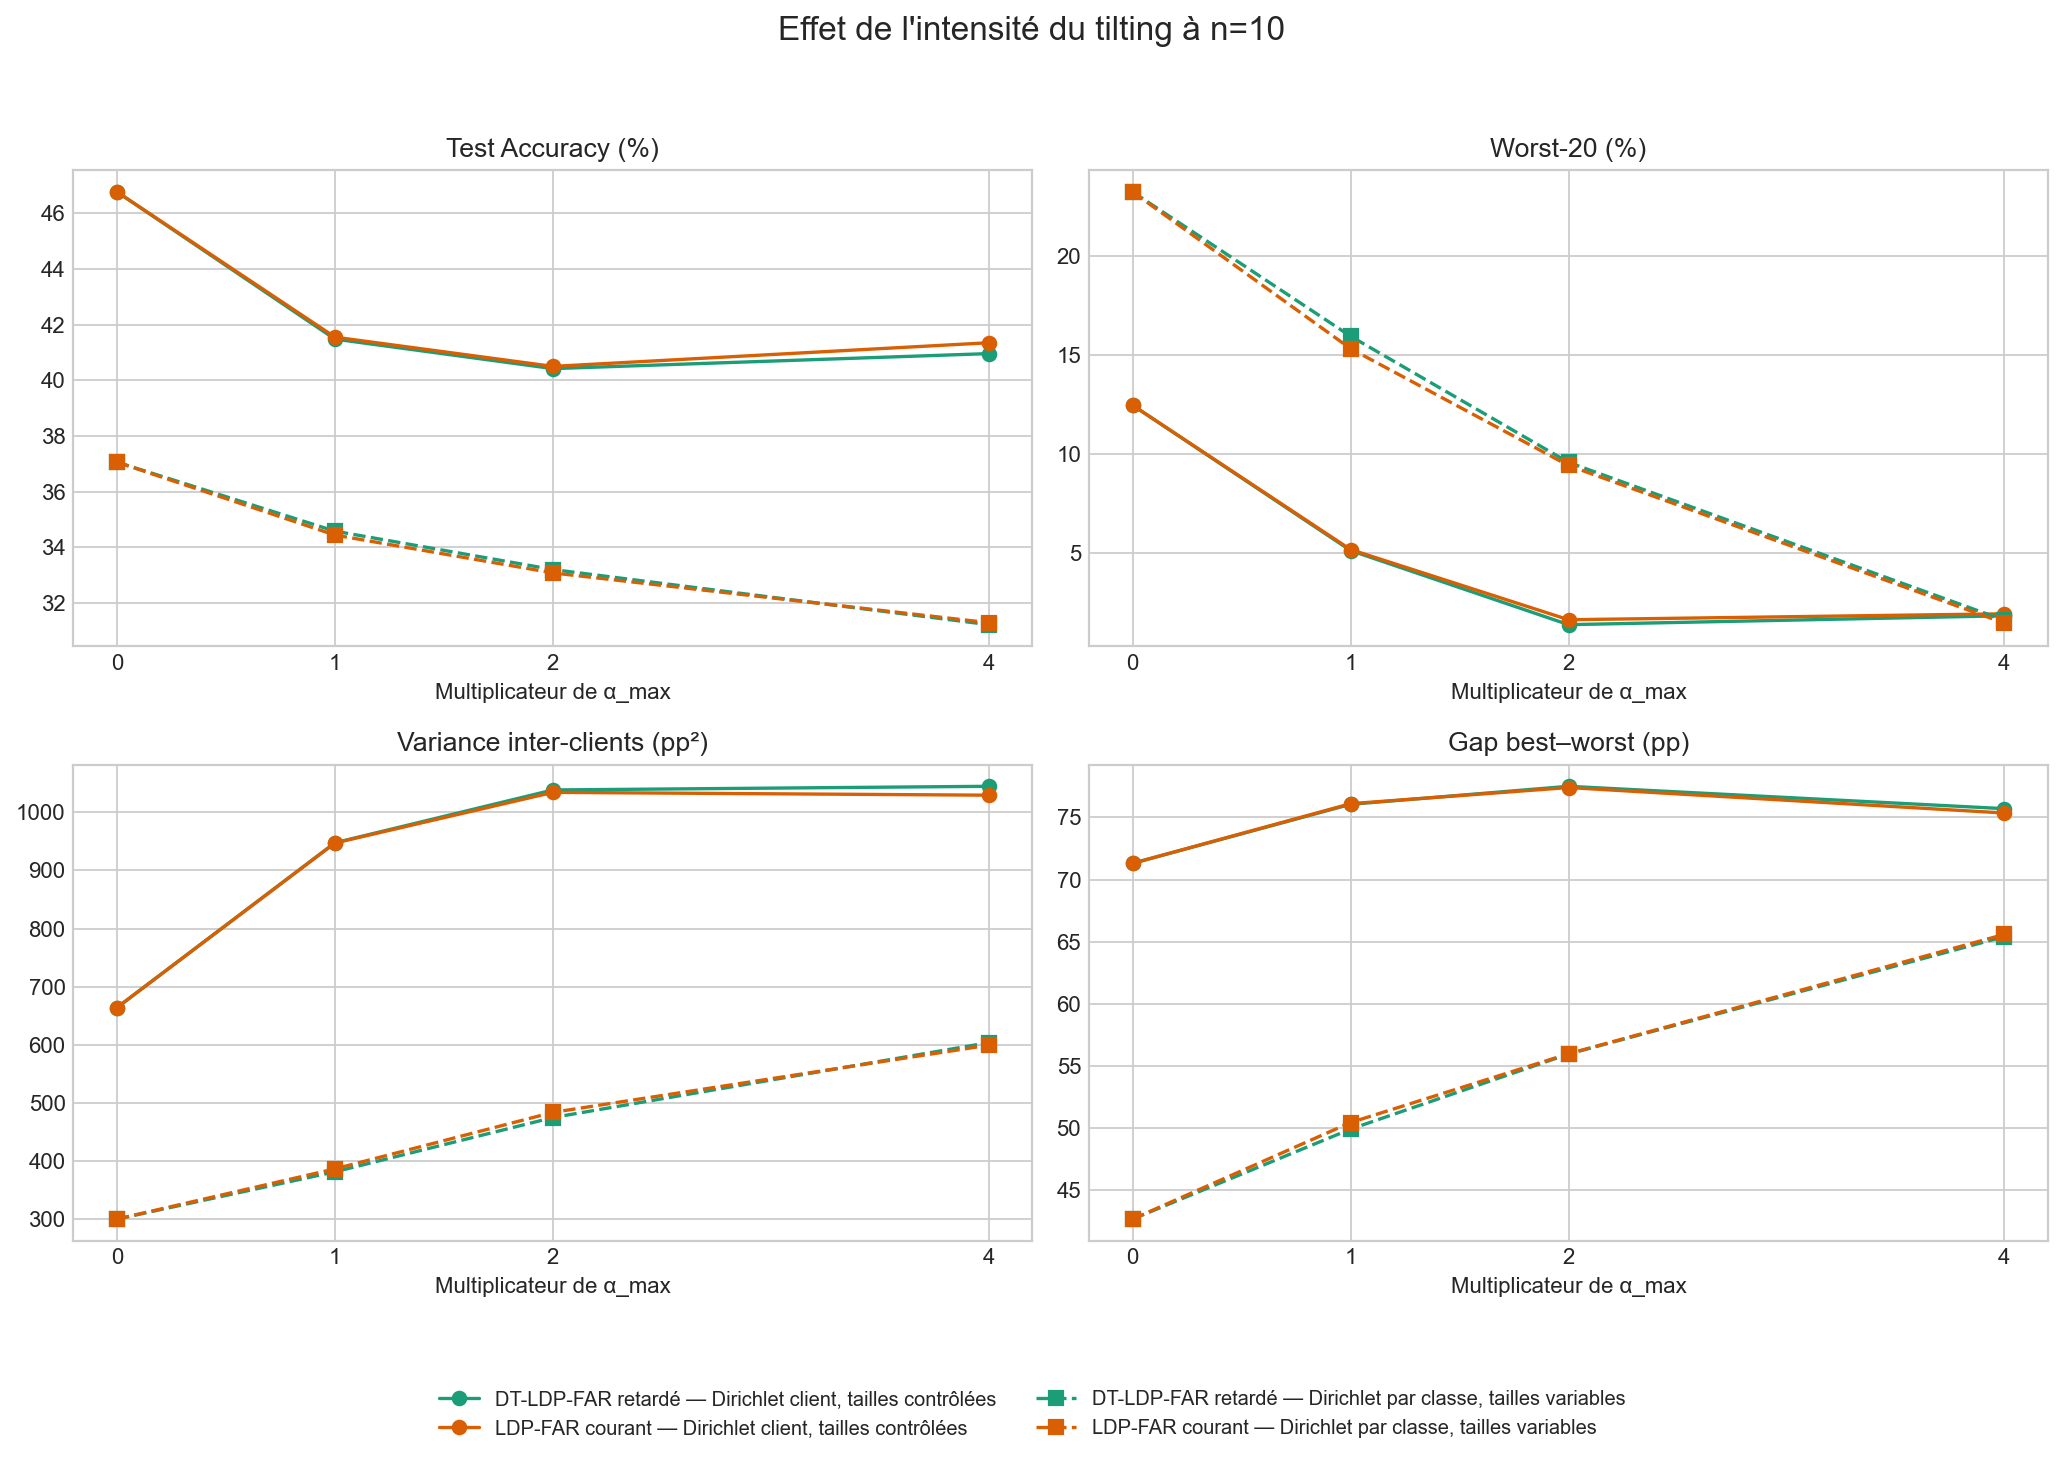

In [5]:
metrics = [
    ("test_acc", "Test Accuracy (%)"),
    ("worst20", "Worst-20 (%)"),
    ("variance_pp2", "Variance inter-clients (pp²)"),
    ("gap", "Gap best–worst (pp)"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = {"LDP-FAR courant": "#D95F02", "DT-LDP-FAR retardé": "#1B9E77"}
markers = {"Dirichlet client, tailles contrôlées": "o", "Dirichlet par classe, tailles variables": "s"}
for ax, (column, title) in zip(axes.ravel(), metrics):
    for (partition, variant), group in n10.groupby(["partition_label", "variant_label"]):
        group = group.sort_values("tilt_multiple")
        ax.plot(group.tilt_multiple, group[column], marker=markers[partition], color=colors[variant],
                linestyle="-" if "contrôlées" in partition else "--",
                label=f"{variant} — {partition}")
    ax.set_title(title)
    ax.set_xlabel("Multiplicateur de α_max")
    ax.set_xticks([0, 1, 2, 4])
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=2, fontsize=9)
fig.suptitle("Effet de l'intensité du tilting à n=10", y=1.01, fontsize=15)
save_show(fig, "n10_alpha_effect_final_metrics.png", rect=(0, 0.10, 1, 0.98));

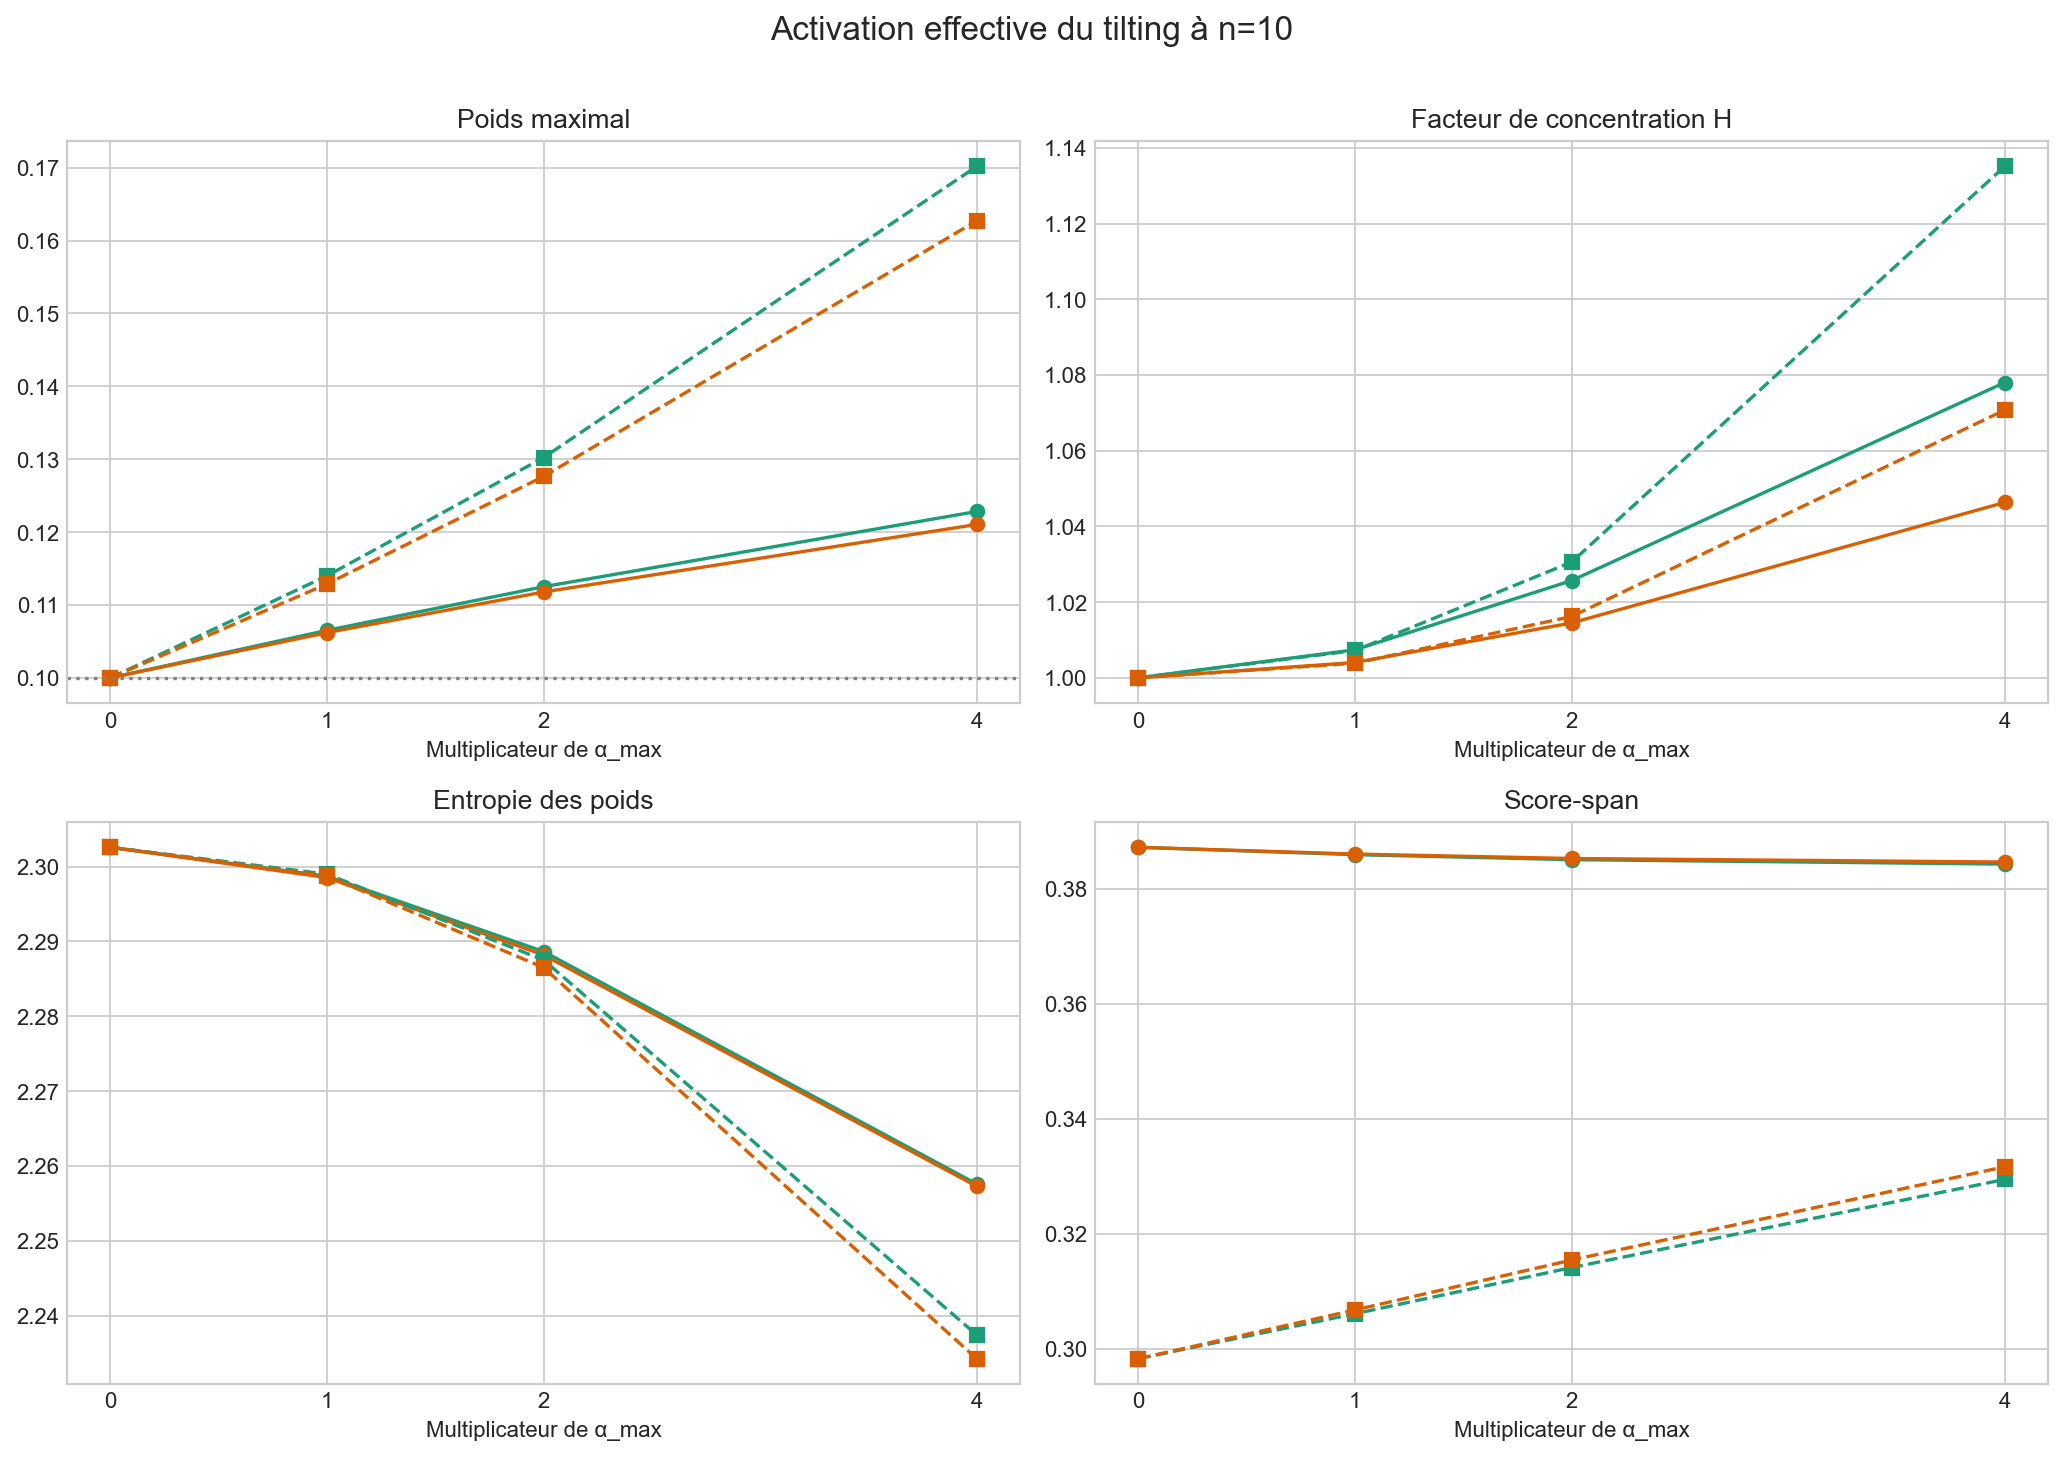

In [6]:
diag_metrics = [
    ("max_weight", "Poids maximal"),
    ("H", "Facteur de concentration H"),
    ("weight_entropy", "Entropie des poids"),
    ("score_span", "Score-span"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (column, title) in zip(axes.ravel(), diag_metrics):
    for (partition, variant), group in n10.groupby(["partition_label", "variant_label"]):
        group = group.sort_values("tilt_multiple")
        ax.plot(group.tilt_multiple, group[column], marker=markers[partition], color=colors[variant],
                linestyle="-" if "contrôlées" in partition else "--",
                label=f"{variant} — {partition}")
    ax.set_title(title)
    ax.set_xlabel("Multiplicateur de α_max")
    ax.set_xticks([0, 1, 2, 4])
axes[0, 0].axhline(0.1, color="gray", linestyle=":", label="Poids uniforme 1/n")
fig.suptitle("Activation effective du tilting à n=10", y=1.01, fontsize=15)
fig.subplots_adjust(bottom=0.08)
save_show(fig, "n10_alpha_weight_diagnostics.png");

### Lecture

Le **gap best–worst** est ici la différence, en points de pourcentage, entre
l'accuracy moyenne des 20 % de clients les meilleurs et celle des 20 % les moins
performants. Un gap plus grand signifie donc une disparité inter-clients plus forte
et est défavorable, même si l'accuracy globale ne baisse pas nécessairement dans la
même proportion.

La figure ne permet pas d'affirmer une monotonie universelle du gap. Pour la
partition Dirichlet par classe à tailles variables, le gap augmente bien de façon
monotone lorsque le multiplicateur passe de 0 à 1, 2 puis 4 : environ 42,7, 50,
56 et 65,5 pp. Pour la partition à tailles contrôlées, il passe d'environ 71,3 pp
à 76,1 puis 77,5 pp, avant de redescendre légèrement à environ 75,5 pp pour
$4\alpha_{\max}$. La conclusion correcte est donc : **augmenter $\alpha$ dégrade
globalement le gap dans ce stress, mais la dégradation n'est pas strictement
monotone dans toutes les partitions**.

Les trois diagnostics de poids donnent des informations complémentaires :

- le **poids maximal** $\max_i\omega_i$ mesure l'influence du client le plus
  favorisé ; sous des poids uniformes et $n=10$, il vaut $1/n=0{,}1$ ;
- le **facteur de concentration** $H=n\sum_i\omega_i^2$ mesure la concentration
  quadratique de toute la distribution. Il vaut 1 pour des poids uniformes et
  augmente quand la masse se concentre sur moins de clients. Le nombre effectif
  quadratique de clients est $n_{\mathrm{eff},2}=1/\sum_i\omega_i^2=n/H$ ; par
  exemple, $H=1{,}25$ avec $n=10$ correspond à $n_{\mathrm{eff},2}=8$ ;
- l'**entropie de Shannon** $\mathcal H(\omega)=-\sum_i\omega_i\log\omega_i$
  décrit la dispersion globale des poids. Elle est maximale à $\log n$ pour la
  distribution uniforme et diminue lorsque les poids deviennent plus inégaux.

Ainsi, lorsque $\alpha$ augmente, la hausse du poids maximal et de $H$, accompagnée
de la baisse de l'entropie, montre que la softmax s'éloigne de l'agrégation uniforme
et concentre l'influence sur un sous-ensemble plus petit de clients. $H$ est
particulièrement sensible aux gros poids, tandis que l'entropie utilise toute la
distribution. Cette observation soutient empiriquement le contrôle de $\alpha$ à
$n=10$ ; le certificat analytique reste toutefois la justification formelle du cap.

### Dégradation explicite au-delà de $\alpha_{\max}$

Les figures précédentes donnent les valeurs absolues. La cellule suivante prend
la lane certifiée $\alpha=\alpha_{\max}$ comme référence et calcule, pour
$2\alpha_{\max}$ et $4\alpha_{\max}$ :

$\Delta M(r)=M(r\alpha_{\max})-M(\alpha_{\max}),\qquad r\in\{2,4\}.$

Une baisse de Test Accuracy ou de Worst-20 est défavorable. Une hausse de la
variance, du gap, du poids maximal ou de $H=n\sum_i\omega_i^2$ est également
défavorable. Les lanes $r>1$ sont des diagnostics non certifiés : elles montrent
ce que le cap empêche, sans revendiquer la garantie $\max_i\omega_i\leq\kappa_w/n$.

,Partition,Variante,α / α_max,Δ Test Acc. (pp),Δ Worst-20 (pp),Δ variance (pp²),Δ gap (pp),Δ poids maximal,Δ H,Critères dégradés / 6
6,"Dirichlet client, tailles contrôlées",DT-LDP-FAR retardé,2.0,-1.06,-3.7500,90.9800,1.4500,0.0060,0.0183,6
7,"Dirichlet client, tailles contrôlées",DT-LDP-FAR retardé,4.0,-0.52,-3.3000,97.2748,-0.3500,0.0163,0.0706,5
4,"Dirichlet client, tailles contrôlées",LDP-FAR courant,2.0,-1.05,-3.5500,87.1355,1.3000,0.0056,0.0104,6
5,"Dirichlet client, tailles contrôlées",LDP-FAR courant,4.0,-0.20,-3.2500,82.3000,-0.7500,0.0148,0.0423,5
2,"Dirichlet par classe, tailles variables",DT-LDP-FAR retardé,2.0,-1.38,-6.3818,93.4894,6.0445,0.0162,0.0233,6
3,"Dirichlet par classe, tailles variables",DT-LDP-FAR retardé,4.0,-3.36,-14.3706,222.5545,15.4916,0.0562,0.1279,6
0,"Dirichlet par classe, tailles variables",LDP-FAR courant,2.0,-1.36,-5.9108,97.3553,5.5347,0.0147,0.0123,6
1,"Dirichlet par classe, tailles variables",LDP-FAR courant,4.0,-3.15,-13.8848,213.0841,15.1419,0.0498,0.0669,6


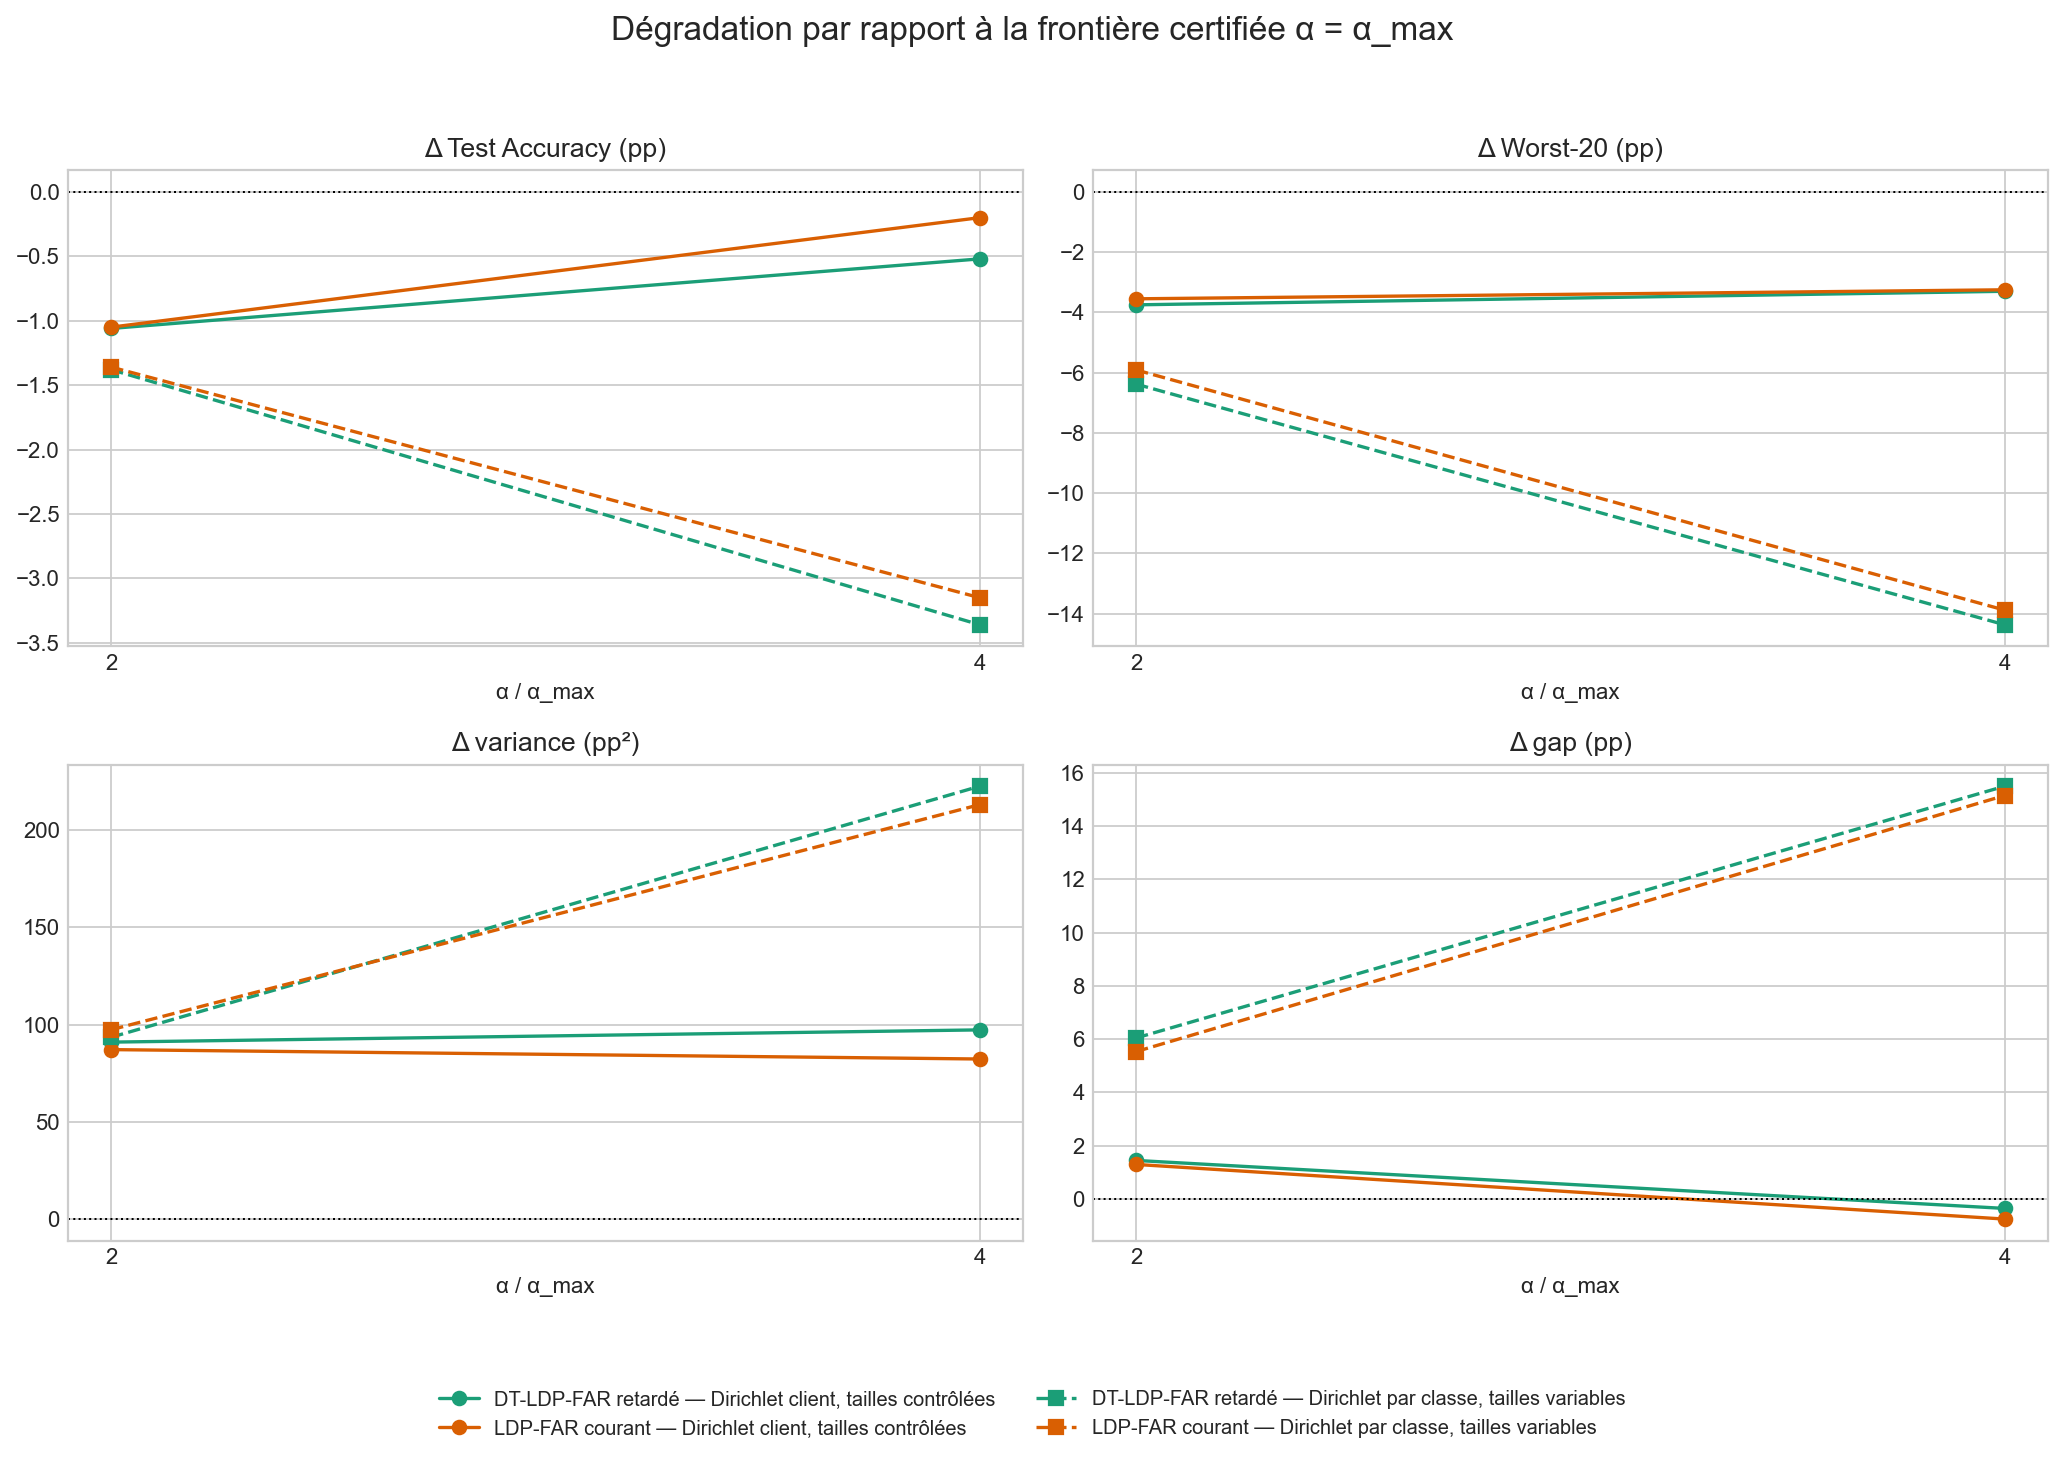

In [7]:
comparison_keys = ["partition_label", "variant_label"]
cap_rows = n10[np.isclose(n10.tilt_multiple, 1.0)].copy()
over_cap = n10[n10.tilt_multiple > 1.0].copy()

cap_metrics = [
    "test_acc", "worst20", "variance_pp2", "gap", "max_weight", "H"
]
alpha_degradation = over_cap.merge(
    cap_rows[comparison_keys + cap_metrics],
    on=comparison_keys,
    how="inner",
    suffixes=("", "_at_alpha_max"),
)

for metric in cap_metrics:
    alpha_degradation[f"delta_{metric}"] = (
        alpha_degradation[metric]
        - alpha_degradation[f"{metric}_at_alpha_max"]
    )

alpha_degradation["degradation_indicators"] = (
    (alpha_degradation.delta_test_acc < 0).astype(int)
    + (alpha_degradation.delta_worst20 < 0).astype(int)
    + (alpha_degradation.delta_variance_pp2 > 0).astype(int)
    + (alpha_degradation.delta_gap > 0).astype(int)
    + (alpha_degradation.delta_max_weight > 0).astype(int)
    + (alpha_degradation.delta_H > 0).astype(int)
)

alpha_degradation_table = alpha_degradation.rename(columns={
    "partition_label": "Partition",
    "variant_label": "Variante",
    "tilt_multiple": "α / α_max",
    "delta_test_acc": "Δ Test Acc. (pp)",
    "delta_worst20": "Δ Worst-20 (pp)",
    "delta_variance_pp2": "Δ variance (pp²)",
    "delta_gap": "Δ gap (pp)",
    "delta_max_weight": "Δ poids maximal",
    "delta_H": "Δ H",
    "degradation_indicators": "Critères dégradés / 6",
})[[
    "Partition", "Variante", "α / α_max", "Δ Test Acc. (pp)",
    "Δ Worst-20 (pp)", "Δ variance (pp²)", "Δ gap (pp)",
    "Δ poids maximal", "Δ H", "Critères dégradés / 6",
]].sort_values(["Partition", "Variante", "α / α_max"])

display(alpha_degradation_table.round(4))
alpha_degradation_table.to_csv(
    EXPORT_ROOT / "n10_alpha_above_cap_degradation.csv", index=False
)

delta_panels = [
    ("delta_test_acc", "Δ Test Accuracy (pp)"),
    ("delta_worst20", "Δ Worst-20 (pp)"),
    ("delta_variance_pp2", "Δ variance (pp²)"),
    ("delta_gap", "Δ gap (pp)"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (column, title) in zip(axes.ravel(), delta_panels):
    for (partition, variant), group in alpha_degradation.groupby(
        ["partition_label", "variant_label"]
    ):
        group = group.sort_values("tilt_multiple")
        ax.plot(
            group.tilt_multiple,
            group[column],
            marker=markers[partition],
            color=colors[variant],
            linestyle="-" if "contrôlées" in partition else "--",
            label=f"{variant} — {partition}",
        )
    ax.axhline(0.0, color="black", linewidth=0.9, linestyle=":")
    ax.set_xticks([2, 4])
    ax.set_xlabel("α / α_max")
    ax.set_title(title)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01),
    ncol=2, fontsize=9
)
fig.suptitle(
    "Dégradation par rapport à la frontière certifiée α = α_max",
    y=1.01,
    fontsize=15,
)
save_show(fig, "n10_alpha_above_cap_degradation.png", rect=(0, 0.10, 1, 0.98));

**Lecture.** Le tableau ne suppose pas que toutes les métriques doivent être
monotones pour chaque seed. Il montre directement quelles métriques se détériorent
par rapport à la frontière certifiée. Le résultat le plus net apparaît sous la
partition Dirichlet par classe : lorsque $\alpha$ passe de $\alpha_{\max}$ à
$4\alpha_{\max}$, Worst-20 chute fortement, tandis que la variance, le gap et la
concentration des poids augmentent. Le contrôle de $\alpha$ est donc à la fois un
certificat d'influence et un garde-fou empirique contre un tilting agressif.

## 3. Le retard d'un tour améliore-t-il l'utilité ?

La comparaison est appariée : même partition, même seed, même α et même budget DP.
La colonne `retardé − courant` isole l'effet observé du retard dans chaque cellule.

In [8]:
paired = n10.pivot_table(
    index=["partition_label", "tilt_multiple", "alpha"],
    columns="variant_label",
    values=["test_acc", "worst20", "variance_pp2", "gap", "H"],
    aggfunc="first",
)
delta = pd.DataFrame(index=paired.index)
for metric in ["test_acc", "worst20", "variance_pp2", "gap", "H"]:
    delta[f"Δ {metric}"] = paired[(metric, "DT-LDP-FAR retardé")] - paired[(metric, "LDP-FAR courant")]
display(delta.reset_index().round(4))
delta.reset_index().to_csv(EXPORT_ROOT / "n10_delay_minus_current.csv", index=False)

,partition_label,tilt_multiple,alpha,Δ test_acc,Δ worst20,Δ variance_pp2,Δ gap,Δ H
0,"Dirichlet client, tailles contrôlées",0.0,0.0000,0.00,0.0000,0.0000,0.0000,0.0000
1,"Dirichlet client, tailles contrôlées",1.0,0.8109,-0.07,-0.0500,0.3351,-0.0500,0.0034
2,"Dirichlet client, tailles contrôlées",2.0,1.6219,-0.08,-0.2500,4.1796,0.1000,0.0112
3,"Dirichlet client, tailles contrôlées",4.0,3.2437,-0.39,-0.1000,15.3099,0.3500,0.0317
4,"Dirichlet par classe, tailles variables",0.0,0.0000,0.00,0.0000,0.0000,0.0000,0.0000
5,"Dirichlet par classe, tailles variables",1.0,0.8109,0.14,0.6287,-5.0558,-0.5303,0.0034
6,"Dirichlet par classe, tailles variables",2.0,1.6219,0.12,0.1577,-8.9217,-0.0204,0.0144
7,"Dirichlet par classe, tailles variables",4.0,3.2437,-0.07,0.1429,4.4147,-0.1806,0.0644


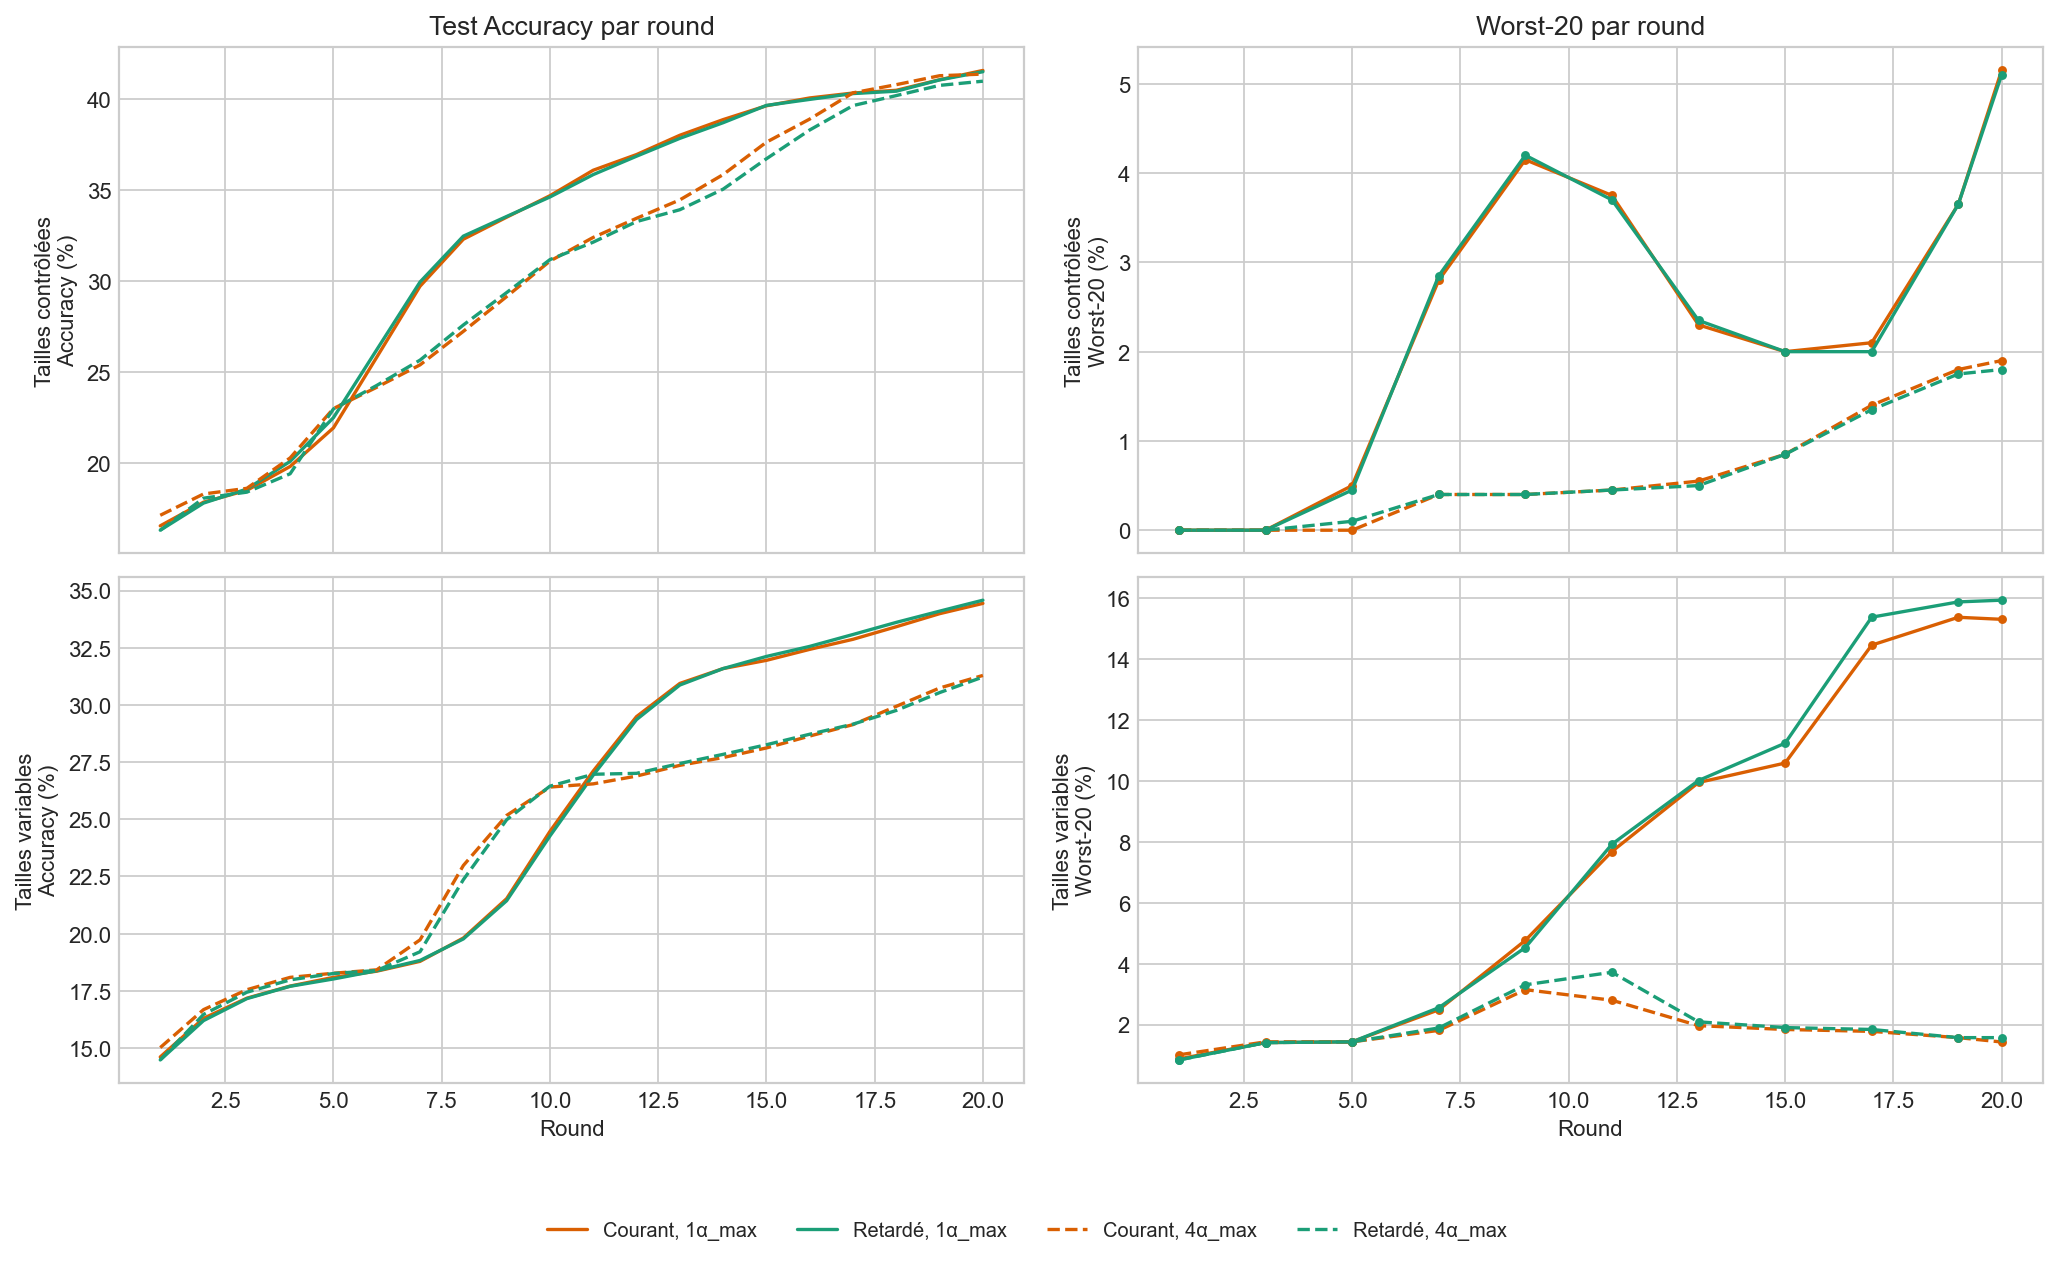

In [9]:
n10_rounds = rounds[rounds.campaign.isin([N10_BAL, N10_CLASS])].copy()
n10_rounds["partition_label"] = n10_rounds.partition.map({
    "client_dirichlet_balanced": "Tailles contrôlées",
    "dirichlet": "Tailles variables",
}).fillna(n10_rounds.partition)
n10_rounds["variant_label"] = n10_rounds.method.map({
    "dp_far_current_matched": "Courant",
    "dt_ldp_far": "Retardé",
}).fillna(n10_rounds.method)
focus = n10_rounds[n10_rounds.tilt_multiple.isin([1.0, 4.0])]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for row_idx, partition in enumerate(["Tailles contrôlées", "Tailles variables"]):
    subset = focus[focus.partition_label == partition]
    for variant, tilt, color, linestyle in [
        ("Courant", 1.0, "#D95F02", "-"), ("Retardé", 1.0, "#1B9E77", "-"),
        ("Courant", 4.0, "#D95F02", "--"), ("Retardé", 4.0, "#1B9E77", "--"),
    ]:
        group = subset[(subset.variant_label == variant) & (subset.tilt_multiple == tilt)].sort_values("round")
        label = f"{variant}, {int(tilt)}α_max"
        axes[row_idx, 0].plot(group["round"], group.test_acc, color=color, linestyle=linestyle, label=label)
        fairness_group = group.dropna(subset=["worst20"])
        axes[row_idx, 1].plot(fairness_group["round"], fairness_group.worst20, color=color, linestyle=linestyle, marker="o", markersize=3, label=label)
    axes[row_idx, 0].set_ylabel(f"{partition}\nAccuracy (%)")
    axes[row_idx, 1].set_ylabel(f"{partition}\nWorst-20 (%)")
axes[0, 0].set_title("Test Accuracy par round")
axes[0, 1].set_title("Worst-20 par round")
axes[1, 0].set_xlabel("Round")
axes[1, 1].set_xlabel("Round")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=4, fontsize=9)
save_show(fig, "n10_current_vs_delayed_trajectories.png", rect=(0, 0.08, 1, 1));

### Lecture

Le retard ne procure pas de gain répétable dans ces cellules. Les écarts finaux
restent petits et leur signe n'est pas favorable de manière constante. Le contrôle
`α = 0` donne exactement la même trajectoire pour les deux branches, ce qui vérifie
que l'implémentation du retard n'introduit pas seule une différence.

Ce résultat ne réfute pas le mécanisme théorique : il montre que le stress n=10
reste trop proche de l'uniforme pour transformer la décorrélation en gain mesurable.

## 4. Le clipping serveur est-il utile ? Ecran complémentaire n=25

Il n'existe pas d'ablation décisive appariée du clipping serveur dans la campagne
n=10. Le tableau suivant reproduit donc l'écran n=25 du rapport complet, avec
`U = 0,28` contre `U = 10` — ce dernier rend le clipping pratiquement inactif.
Cette ancienne géométrie sature les scores à n=25 ; le résultat est informatif pour
la borne de norme, mais pas pour l'effet du tilting.

,threat,U_label,test_acc,worst20,gap,honest_clip,byz_clip,byz_contrib,score_saturation,score_span
203,alie20_n25,"U=0,28",44.79,8.3125,69.4375,1.0,0.0,0.0074,0.8,0.8038
204,alie20_n25,U=10 (inactif),47.64,8.5625,67.5625,0.0,0.0,0.0070,0.8,0.7981
205,bf20_n25_s10,"U=0,28",34.92,4.3750,71.6875,1.0,1.0,0.0248,1.0,0.0000
206,bf20_n25_s10,U=10 (inactif),9.99,0.0000,44.3750,0.0,0.0,0.6147,1.0,0.0000
207,none,"U=0,28",45.29,7.2000,62.9500,1.0,NaN,0.0000,1.0,0.0000
208,none,U=10 (inactif),45.51,8.0000,61.9000,0.0,NaN,0.0000,1.0,0.0000


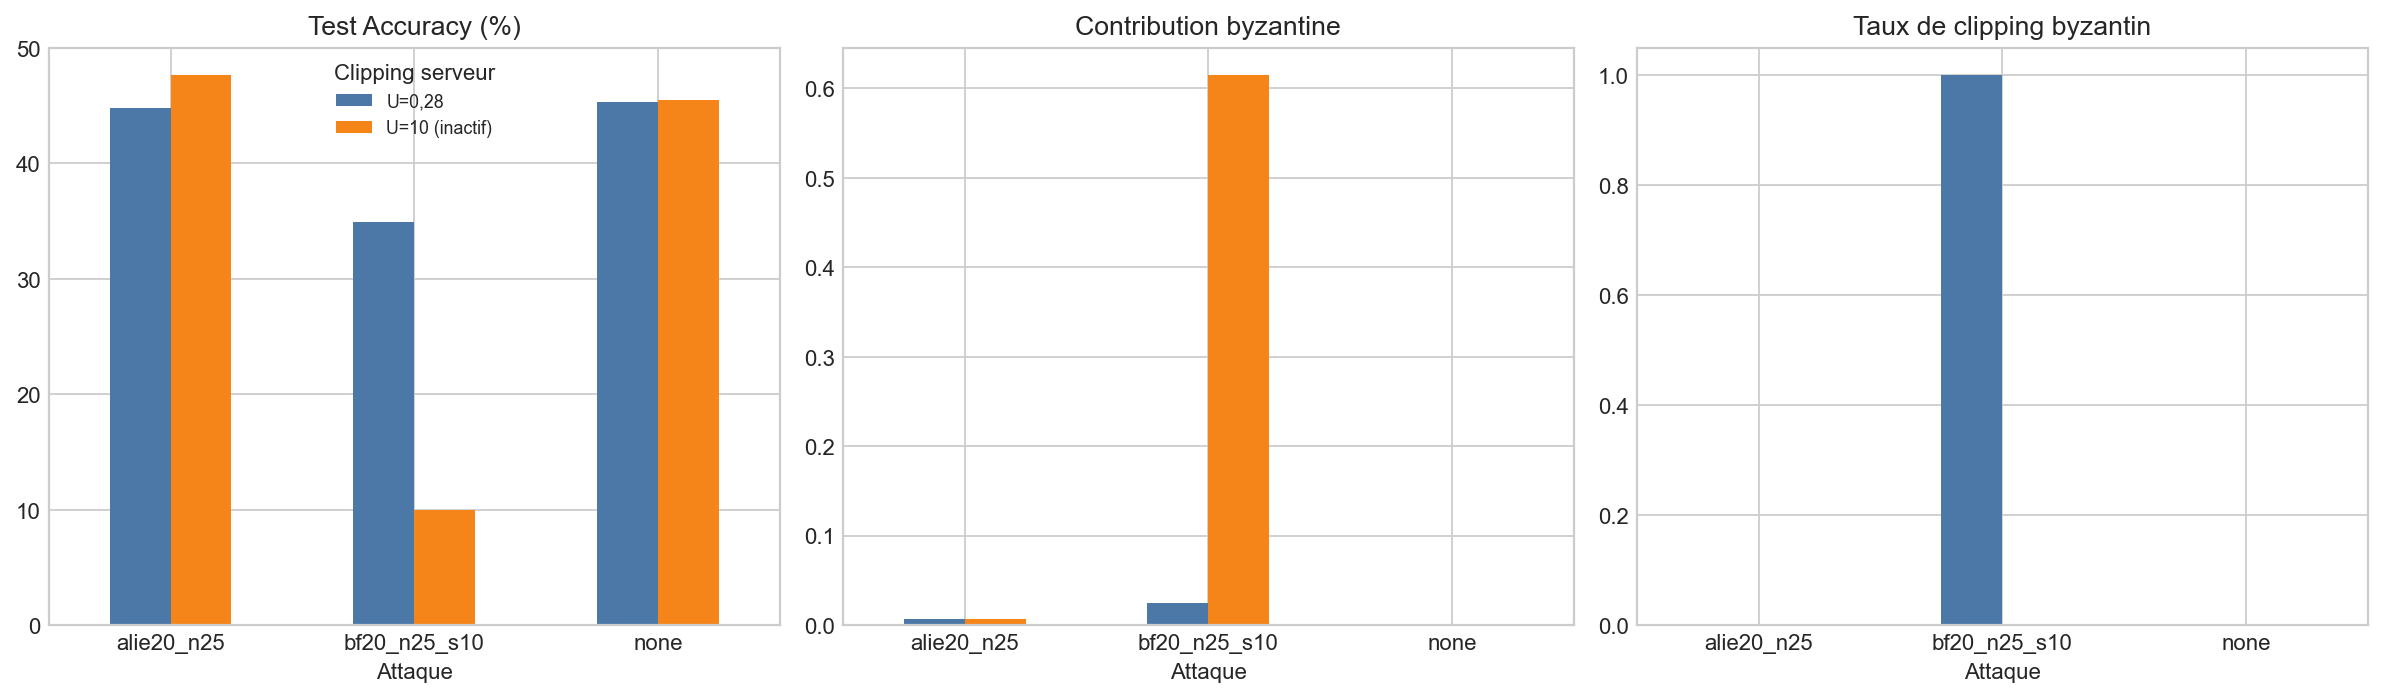

In [10]:
CLIP_CAMPAIGN = "dt_ldp_far_decisive_stage1_server_clip_ablation_n25_c4_v1"
clip_df = runs[runs.campaign == CLIP_CAMPAIGN].copy()
clip_df["U_label"] = clip_df.U.map(lambda x: "U=0,28" if x < 1 else "U=10 (inactif)")
clip_table = clip_df[["threat", "U_label", "test_acc", "worst20", "gap", "honest_clip", "byz_clip", "byz_contrib", "score_saturation", "score_span"]].sort_values(["threat", "U_label"])
display(clip_table.round(4))
clip_table.to_csv(EXPORT_ROOT / "n25_legacy_server_clip_ablation.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, title in zip(
    axes,
    ["test_acc", "byz_contrib", "byz_clip"],
    ["Test Accuracy (%)", "Contribution byzantine", "Taux de clipping byzantin"],
):
    pivot = clip_df.pivot(index="threat", columns="U_label", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0, color=["#4C78A8", "#F58518"])
    ax.set_title(title)
    ax.set_xlabel("Attaque")
    if ax is not axes[0]:
        ax.get_legend().remove()
axes[0].legend(title="Clipping serveur", fontsize=8)
save_show(fig, "n25_legacy_server_clip_ablation.png");

### Certificat d'influence associé au clipping serveur

L'ablation précédente montre l'effet empirique du clipping sous Bit-Flip.
La propriété « influence bornée » est distincte : elle découle de la norme
serveur et du cap des poids. Si

$
\lVert X_{i,t}\rVert_2\leq U,
\qquad
\omega_{i,t}\leq\frac{\kappa_w}{n},
$

alors un client contribue au plus

$
\lVert\omega_{i,t}X_{i,t}\rVert_2
\leq\frac{\kappa_w U}{n},
$

et l'ensemble de $b$ clients byzantins contribue au plus

$
\left\lVert\sum_{i\in\mathcal B}\omega_{i,t}X_{i,t}\right\rVert_2
\leq\frac{b\kappa_w U}{n}.
$

La cellule suivante instancie ce certificat pour l'ablation à 25 clients.

In [11]:
certificate_n = 25
certificate_b = 5
certificate_kappa_w = 2.0
certificate_U = 0.28

individual_bound = certificate_kappa_w * certificate_U / certificate_n
byzantine_cohort_bound = (
    certificate_b * certificate_kappa_w * certificate_U / certificate_n
)
bitflip_clipped = clip_df[
    (clip_df.threat == "bf20_n25_s10") & np.isclose(clip_df.U, certificate_U)
].iloc[0]
observed_byzantine_contribution = float(bitflip_clipped.byz_contrib)

certificate_table = pd.DataFrame([
    {
        "Quantité": "Contribution maximale d'un client",
        "Valeur ou borne": individual_bound,
        "Interprétation": "borne analytique κ_w U / n",
    },
    {
        "Quantité": "Contribution maximale des 5 Byzantins",
        "Valeur ou borne": byzantine_cohort_bound,
        "Interprétation": "borne analytique b κ_w U / n",
    },
    {
        "Quantité": "Contribution byzantine observée — Bit-Flip ×10",
        "Valeur ou borne": observed_byzantine_contribution,
        "Interprétation": "doit rester sous la borne de cohorte",
    },
])
certificate_table["Ratio observé / borne de cohorte"] = np.nan
certificate_table.loc[2, "Ratio observé / borne de cohorte"] = (
    observed_byzantine_contribution / byzantine_cohort_bound
)
display(certificate_table.round(5))
print(
    "Certificat respecté :",
    observed_byzantine_contribution <= byzantine_cohort_bound + 1e-12,
)

,Quantité,Valeur ou borne,Interprétation,Ratio observé / borne de cohorte
0,Contribution maximale d'un client,0.02240,borne analytique κ_w U / n,NaN
1,Contribution maximale des 5 Byzantins,0.11200,borne analytique b κ_w U / n,NaN
2,Contribution byzantine observée — Bit-Flip ×10,0.02485,doit rester sous la borne de cohorte,0.22186


Certificat respecté : True


**Conclusion.** L'expérience illustre la réduction effective d'une attaque de
grande norme ; les inégalités établissent la borne d'influence. Ici, la
contribution byzantine observée reste sous la borne de cohorte. Cela ne montre
pas que le seuil $U=0{,}28$ est optimal : ALIE peut rester sous le seuil et les
uploads honnêtes peuvent être excessivement clippés.

### Lecture

Le clipping serveur est utile contre une attaque de grande norme : sous Bit-Flip
amplifié, il réduit fortement la contribution byzantine et évite l'effondrement.
Il ne détecte pas ALIE, qui reste à l'intérieur de la géométrie honnête. Le clipping
serveur est donc une borne d'influence nécessaire, pas un mécanisme universel de
détection Byzantine. Une nouvelle ablation avec la géométrie n=25 recalibrée reste
nécessaire pour une conclusion causale propre.

## 5. F_CC est-elle empiriquement la meilleure référence ? écran complémentaire n=25

Cette question n'a pas été testée dans la campagne décisive n=10. Le screen ci-dessous
est celui du rapport complet : cinq références, six conditions et une seule seed.
Une faible erreur à la moyenne honnête n'est pas une preuve de robustesse générale.

reference_label,CM(NNM),F_CC,Huber,RFA,trMean(NNM)
threat,,,,,
alie20_n25,44.77,44.79,44.79,44.81,44.78
bf20_n25,34.92,34.92,34.92,34.92,34.92
ipm20_n25,40.74,41.05,41.07,41.08,40.74
minmax20_n25,4.10,4.10,4.10,4.10,4.10
minsum20_n25,5.20,5.20,5.20,5.20,5.20
none,45.29,45.29,45.29,45.29,45.29


,threat,reference_label,test_acc,reference_error,reference_drift,byz_mass,byz_contrib,score_span,score_saturation
173,alie20_n25,CM(NNM),44.77,0.0233,0.0662,0.1258,0.0076,0.7494,0.8
179,alie20_n25,F_CC,44.79,0.0379,0.0324,0.1215,0.0074,0.8038,0.8
185,alie20_n25,Huber,44.79,0.0462,0.0208,0.1223,0.0074,0.7954,0.8
191,alie20_n25,RFA,44.81,0.0699,0.0742,0.1083,0.0066,0.9812,0.8
197,alie20_n25,trMean(NNM),44.78,0.0226,0.0655,0.1255,0.0076,0.7534,0.8
174,bf20_n25,CM(NNM),34.92,0.0303,0.0671,0.2000,0.0248,0.0000,1.0
180,bf20_n25,F_CC,34.92,0.0474,0.0276,0.2000,0.0248,0.0000,1.0
186,bf20_n25,Huber,34.92,0.0539,0.0193,0.2000,0.0248,0.0000,1.0
192,bf20_n25,RFA,34.92,0.0315,0.0660,0.2000,0.0248,0.0000,1.0
198,bf20_n25,trMean(NNM),34.92,0.0302,0.0668,0.2000,0.0248,0.0000,1.0


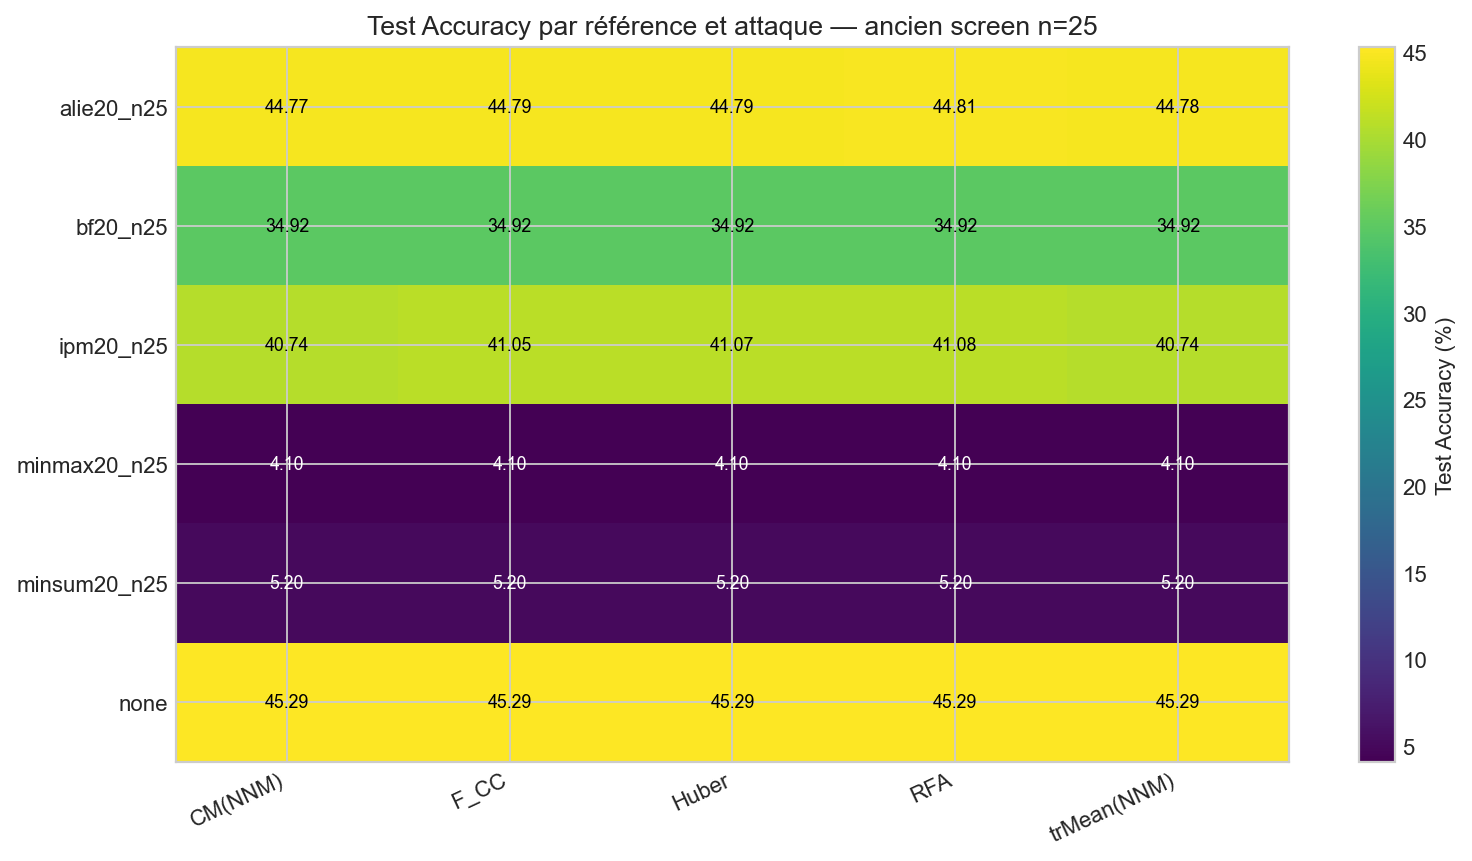

In [12]:
REF_CAMPAIGN = "dt_ldp_far_decisive_stage1_references_attacks_n25_v1"
refs = runs[runs.campaign == REF_CAMPAIGN].copy()
ref_names = {"fcc": "F_CC", "huber": "Huber", "cm_nnm": "CM(NNM)", "trmean_nnm": "trMean(NNM)", "rfa": "RFA"}
refs["reference_label"] = refs.reference.map(ref_names).fillna(refs.reference)

accuracy_pivot = refs.pivot(index="threat", columns="reference_label", values="test_acc")
display(accuracy_pivot.round(2))

diagnostics = refs[["threat", "reference_label", "test_acc", "reference_error", "reference_drift", "byz_mass", "byz_contrib", "score_span", "score_saturation"]].sort_values(["threat", "reference_label"])
display(diagnostics.round(4))
accuracy_pivot.to_csv(EXPORT_ROOT / "n25_legacy_reference_accuracy.csv")
diagnostics.to_csv(EXPORT_ROOT / "n25_legacy_reference_diagnostics.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
image = ax.imshow(accuracy_pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(accuracy_pivot.columns)), accuracy_pivot.columns, rotation=25, ha="right")
ax.set_yticks(range(len(accuracy_pivot.index)), accuracy_pivot.index)
for i in range(accuracy_pivot.shape[0]):
    for j in range(accuracy_pivot.shape[1]):
        ax.text(j, i, f"{accuracy_pivot.iloc[i, j]:.2f}", ha="center", va="center", color="white" if accuracy_pivot.iloc[i, j] < accuracy_pivot.values.mean() else "black", fontsize=8)
ax.set_title("Test Accuracy par référence et attaque — ancien screen n=25")
fig.colorbar(image, ax=ax, label="Test Accuracy (%)")
save_show(fig, "n25_legacy_reference_heatmap.png");

### Lecture

F_CC n'est pas le gagnant empirique de ce screen. Huber présente moins de drift,
RFA réduit davantage la masse byzantine sous certaines attaques furtives, tandis
que CM(NNM) et trMean(NNM) sont parfois plus proches de la moyenne honnête. Les
différences finales de performance sont toutefois minuscules ou rendues non
informatives par la saturation, et une seule seed est disponible.

La formulation correcte est donc : **F_CC est le candidat principal grâce à son
certificat de stabilité, pas grâce à une supériorité empirique démontrée.**

## 6. Le score FAR confond-il signal utile et niveau de bruit DP ?

Le stress Stage 5 à $n=25$ compare 12 paires courant/retardé, avec les mêmes
partitions et les mêmes tirages aléatoires. Pour chaque client, le diagnostic
mesure d'abord la corrélation brute entre le poids courant et la norme de la
perturbation DP effective. Il recalcule ensuite cette corrélation après division
de la perturbation par son échelle DP publique.

### Isotropie, bruit homogène et bruit hétéroscédastique

Ces notions décrivent deux axes différents : la forme du bruit **à l'intérieur
d'un client** et son niveau **d'un client à l'autre**.

- Un bruit est **isotrope** lorsque sa covariance est de la forme
  $\Sigma_{i,t}=\nu_{i,t}^2 I$. Il a la même variance dans toutes les directions
  de l'espace des paramètres et aucune direction n'est privilégiée. Géométriquement,
  ses contours de densité sont sphériques.
- Le bruit est **homogène entre clients** lorsque tous les clients ont la même
  échelle publique, par exemple $\nu_{1,t}=\cdots=\nu_{n,t}$. À mécanismes et
  tailles comparables, aucun client n'est mécaniquement plus éloigné de la référence
  simplement parce que son bruit a une variance plus grande.
- Le bruit est **hétéroscédastique entre clients** lorsque son niveau varie avec le
  client : il existe $i\neq j$ tels que $\nu_{i,t}\neq\nu_{j,t}$. Un client plus
  bruité peut alors recevoir un score euclidien plus grand même si son update propre
  n'est pas plus atypique.

Un bruit peut donc être simultanément **isotrope et hétéroscédastique** : chaque
client a $\Sigma_{i,t}=\nu_{i,t}^2 I$, mais les valeurs $\nu_{i,t}$ diffèrent entre
clients. À l'inverse, un bruit anisotrope possède une covariance qui n'est pas un
simple multiple de $I$ : certaines directions sont plus bruitées ou corrélées que
d'autres.

Dans le cas isotrope, une première correction de score serait

$\widetilde d_{i,t} = \frac{\lVert X_{i,t}-F_t\rVert_2} {\sqrt{\nu_{i,t}^2+\nu_{F,t}^2+\lambda}},$

- $\nu_{i,t}$ est l'échelle effective et publique du bruit du client ;
- $\nu_{F,t}$ représente l'incertitude de la référence ;
- $\lambda>0$ évite une division instable.

et sa généralisation covariance-aware serait

$\widetilde d_{i,t}^{2} = (X_{i,t}-F_t)^\top (\Sigma_{i,t}+\Sigma_{F,t}+\lambda I)^{-1} (X_{i,t}-F_t).$

La campagne ne teste pas encore cette nouvelle pondération. Elle teste le
diagnostic qui la motive : une corrélation brute disparaissant ou changeant de
signe après correction indique que le score euclidien confond l'échelle de bruit
avec l'écart utile du client.

,Configuration,Sous-espace,Dimension,Plage moyenne des logits,Corrélation brute poids-bruit,Corrélation après correction d'échelle,Concentration H,Erreur bruit courant / retardé,Δ accuracy retardé-courant (pp),Seeds passant le gate / 3
0,256 coordonnées publiques,public_coordinates,256,0.3585,0.5065,0.5065,1.0062,1.0001,-0.0367,0
2,Dernière couche,last_layer,850,0.0000,NaN,NaN,1.0000,1.0000,0.0000,0
1,Score complet — bruit homogène,full,61706,0.0462,-0.1387,-0.1387,1.0001,1.0000,0.0133,0
3,Score complet — bruit hétéroscédastique,full,61706,3.0729,0.9467,-0.7712,1.4284,0.9848,0.6500,0


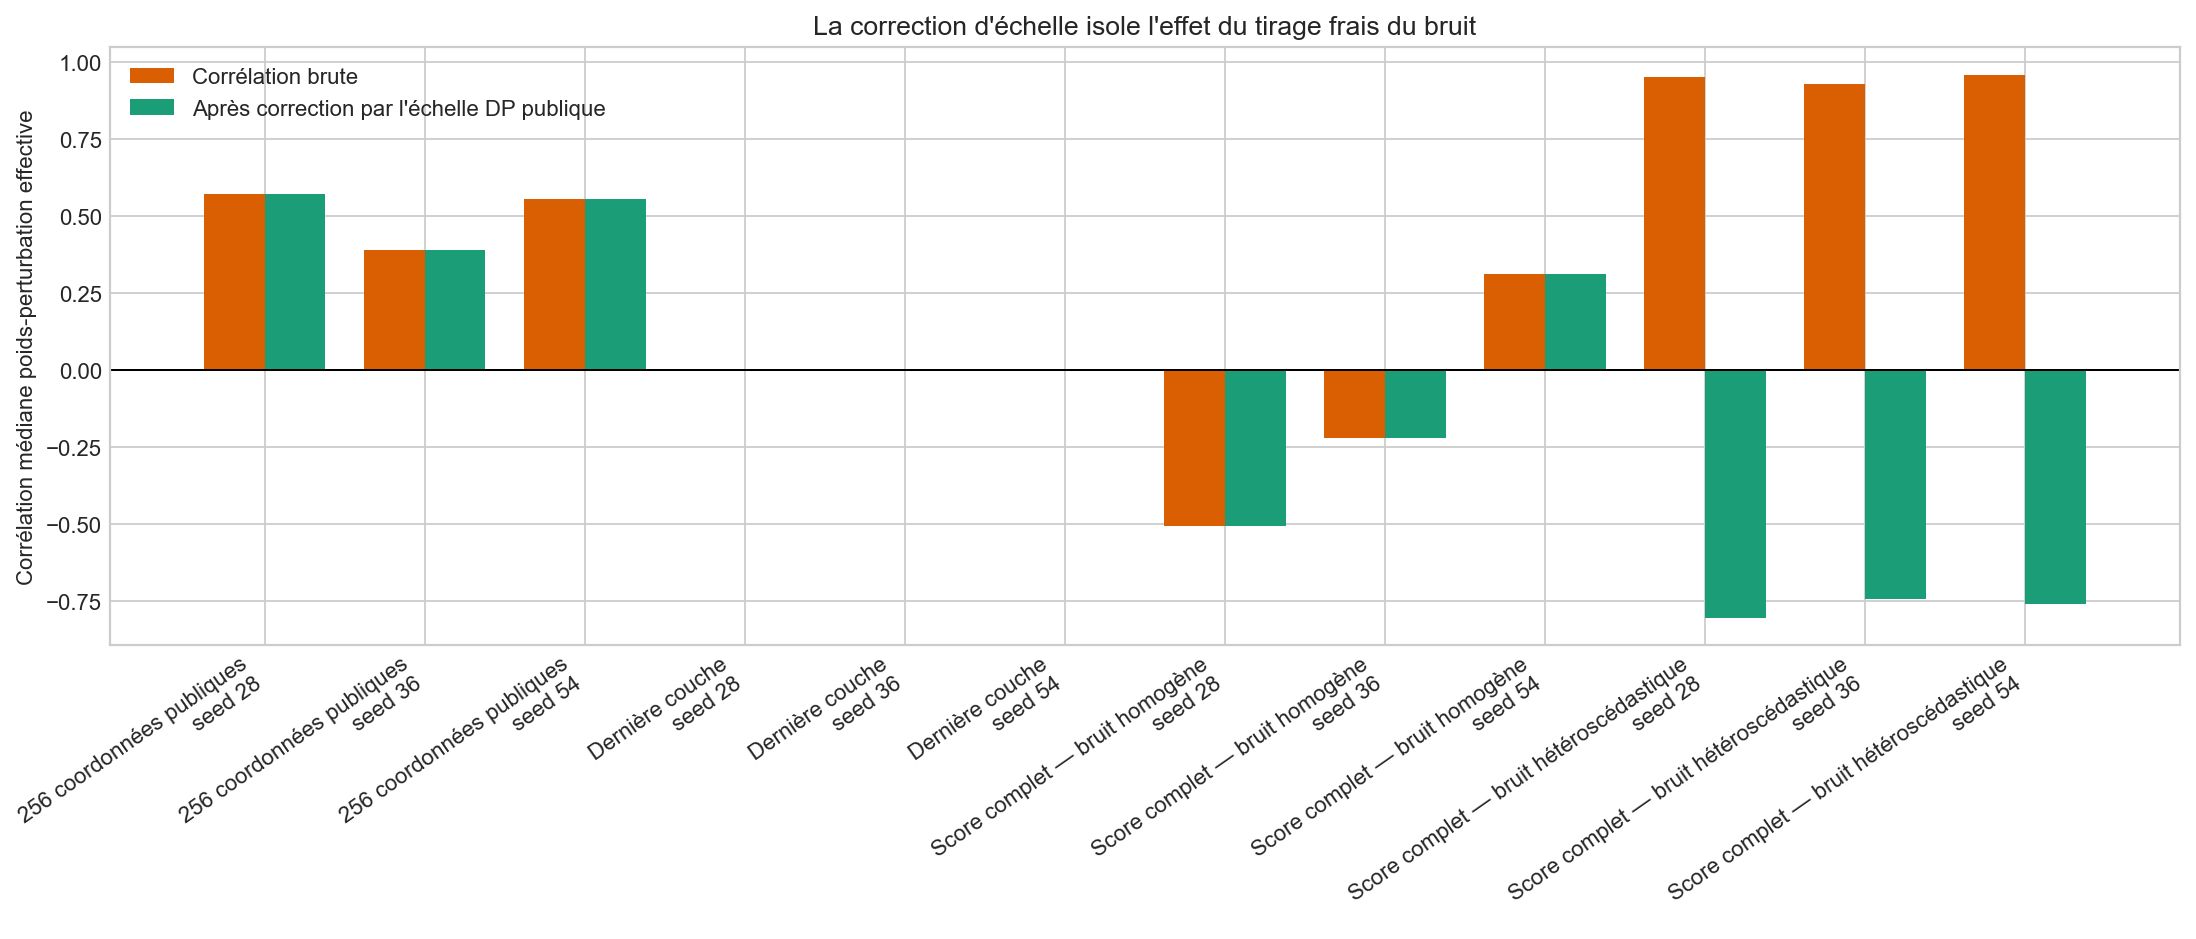

In [13]:
STAGE5_DIR = REPO_ROOT / "output" / "analysis" / "dt_ldp_far_n25_stage5_stress"
candidate_path = STAGE5_DIR / "candidate_summary.csv"
pair_path = STAGE5_DIR / "paired_seed_gate.csv"
if not candidate_path.exists() or not pair_path.exists():
    raise FileNotFoundError(
        "Exécuter scripts/analyze_dt_ldp_far_stage5_stress.py avant cette cellule."
    )

stage5_candidates = pd.read_csv(candidate_path)
stage5_pairs = pd.read_csv(pair_path)

def stage5_label(row):
    if "hetero" in str(row["privacy"]):
        return "Score complet — bruit hétéroscédastique"
    if "coord256" in str(row["geometry"]):
        return "256 coordonnées publiques"
    if "last" in str(row["geometry"]):
        return "Dernière couche"
    return "Score complet — bruit homogène"

stage5_candidates["Configuration"] = stage5_candidates.apply(stage5_label, axis=1)
stage5_candidates["mean_delta_test_pp"] = (
    100 * stage5_candidates.mean_delta_test_delayed_minus_current
)

noise_hypothesis_table = stage5_candidates.rename(columns={
    "score_subspace_mode": "Sous-espace",
    "score_subspace_dimension": "Dimension",
    "seeds_passing_core_gate": "Seeds passant le gate / 3",
    "mean_logit_span": "Plage moyenne des logits",
    "mean_effective_noise_corr": "Corrélation brute poids-bruit",
    "mean_normalized_effective_noise_corr": "Corrélation après correction d'échelle",
    "mean_concentration": "Concentration H",
    "mean_current_delay_noise_ratio": "Erreur bruit courant / retardé",
    "mean_delta_test_pp": "Δ accuracy retardé-courant (pp)",
})[[
    "Configuration", "Sous-espace", "Dimension",
    "Plage moyenne des logits", "Corrélation brute poids-bruit",
    "Corrélation après correction d'échelle", "Concentration H",
    "Erreur bruit courant / retardé", "Δ accuracy retardé-courant (pp)",
    "Seeds passant le gate / 3",
]].sort_values("Configuration")

display(noise_hypothesis_table.round(4))
noise_hypothesis_table.to_csv(
    EXPORT_ROOT / "n25_noise_scale_hypothesis_summary.csv", index=False
)

stage5_pairs["Configuration"] = stage5_pairs.apply(stage5_label, axis=1)
plot_pairs = stage5_pairs.sort_values(["Configuration", "training_seed"]).copy()
positions = np.arange(len(plot_pairs))
width = 0.38
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    positions - width / 2,
    plot_pairs.effective_noise_corr_median,
    width,
    label="Corrélation brute",
    color="#D95F02",
)
ax.bar(
    positions + width / 2,
    plot_pairs.normalized_effective_noise_corr_median,
    width,
    label="Après correction par l'échelle DP publique",
    color="#1B9E77",
)
ax.axhline(0.0, color="black", linewidth=0.9)
ax.set_xticks(positions)
ax.set_xticklabels(
    [f"{label}\nseed {seed}" for label, seed in zip(
        plot_pairs.Configuration, plot_pairs.training_seed
    )],
    rotation=35,
    ha="right",
)
ax.set_ylabel("Corrélation médiane poids-perturbation effective")
ax.set_title("La correction d'échelle isole l'effet du tirage frais du bruit")
ax.legend()
save_show(fig, "n25_raw_vs_noise_scale_corrected_correlation.png");

### Lecture et décision

Dans le régime hétéroscédastique, la corrélation brute est très forte et positive
($\simeq0{,}947$), mais elle devient fortement négative après correction par
l'échelle publique ($\simeq-0{,}771$). Le score FAR euclidien réagit donc surtout
au **niveau de bruit assigné au client**, et non à une réalisation fraîche
accidentellement grande. Cette observation motive un score standardisé ; elle ne
démontre pas encore que ce score améliorera accuracy ou fairness.

Les trois mécanismes restent complémentaires :

- la standardisation par $\Sigma_i$ rend les distances comparables entre clients ;
- le clipping serveur borne la norme des uploads déjà privés et l'influence des
  messages de grande norme ;
- le cap sur $\alpha$ borne la concentration produite par la softmax, même si les
  scores standardisés sont imparfaits ou attaqués.

La standardisation ne remplace donc ni le clipping serveur ni le contrôle de
$\alpha$. La prochaine expérience doit comparer, à randomness appariée, le score
euclidien brut, le score corrigé par l'échelle isotrope et la distance de
Mahalanobis, sans sélectionner la variante d'après son accuracy finale.

## Décision finale : arrêter cette instanciation, pas la local-DP

La conclusion négative porte sur **l'hypothèse d'utilité de l'instanciation
DT-LDP-FAR étudiée**. Elle ne dit pas que la confidentialité locale est inutile
ou impossible. Les expériences séparent deux questions :

1. le mécanisme respecte-t-il ses contrôles de confidentialité et de sécurité ?
2. ces contrôles produisent-ils un gain reproductible d'accuracy ou de fairness ?

La première réponse est positive ; la seconde est négative. Les cellules
suivantes reconstruisent ce verdict depuis le fichier de décision cumulatif,
sans sélectionner une seed ou une attaque favorable.

In [14]:
FINAL_DECISION_PATH = (
    REPO_ROOT / "results" / "dt_ldp_far"
    / "final_decision_stage22_to_stage26.json"
)
if not FINAL_DECISION_PATH.exists():
    raise FileNotFoundError(FINAL_DECISION_PATH)

final_decision = read_json(FINAL_DECISION_PATH)
stage26b = final_decision["stage26b"]

decision_table = pd.DataFrame([
    {
        "Question": "Budget DP apparié ?",
        "Résultat": "Oui",
        "Preuve enregistrée": (
            f"écart maximal d'epsilon = "
            f"{stage26b['privacy_epsilon_difference_max']:.1f}"
        ),
        "Verdict": "validé",
    },
    {
        "Question": "Cap des poids respecté ?",
        "Résultat": "Oui",
        "Preuve enregistrée": "aucune violation dans les campagnes",
        "Verdict": "validé",
    },
    {
        "Question": "Appariement aléatoire strict ?",
        "Résultat": "Oui",
        "Preuve enregistrée": (
            f"taux = {stage26b['strict_randomness_pair_rate']:.1f}"
        ),
        "Verdict": "validé",
    },
    {
        "Question": "Confinement déterministe respecté ?",
        "Résultat": "Oui",
        "Preuve enregistrée": (
            f"norme médiane {stage26b['candidate_correction_norm_median']:.6f} "
            f"≤ borne {stage26b['candidate_correction_universal_bound']:.3f}"
        ),
        "Verdict": "validé",
    },
    {
        "Question": "Gain d'utilité reproductible ?",
        "Résultat": "Non",
        "Preuve enregistrée": (
            f"correction FAR : {stage26b['correction_attacked_accuracy_gain_mean_pp']:+.3f} "
            "pp sous attaque"
        ),
        "Verdict": "rejeté",
    },
    {
        "Question": "Gain sous chaque attaque ?",
        "Résultat": "Non",
        "Preuve enregistrée": (
            f"ancre : Bit-Flip "
            f"{stage26b['anchor_attacked_accuracy_gain_by_attack_pp']['bf20_n25_s10']:+.3f} pp ; "
            f"IPM {stage26b['anchor_attacked_accuracy_gain_by_attack_pp']['ipm20_n25']:+.3f} pp"
        ),
        "Verdict": "rejeté",
    },
])

print(f"Runs agrégés : {final_decision['evaluated_runs']}")
print(f"Statut : {final_decision['status']}")
display(decision_table)
decision_table.to_csv(
    EXPORT_ROOT / "dt_ldp_far_final_decision_table.csv", index=False
)

Runs agrégés : 174
Statut : negative_validation_complete


,Question,Résultat,Preuve enregistrée,Verdict
0,Budget DP apparié ?,Oui,écart maximal d'epsilon = 0.0,validé
1,Cap des poids respecté ?,Oui,aucune violation dans les campagnes,validé
2,Appariement aléatoire strict ?,Oui,taux = 1.0,validé
3,Confinement déterministe respecté ?,Oui,norme médiane 0.002492 ≤ borne 0.210,validé
4,Gain d'utilité reproductible ?,Non,correction FAR : -0.032 pp sous attaque,rejeté
5,Gain sous chaque attaque ?,Non,ancre : Bit-Flip +2.903 pp ; IPM -0.377 pp,rejeté


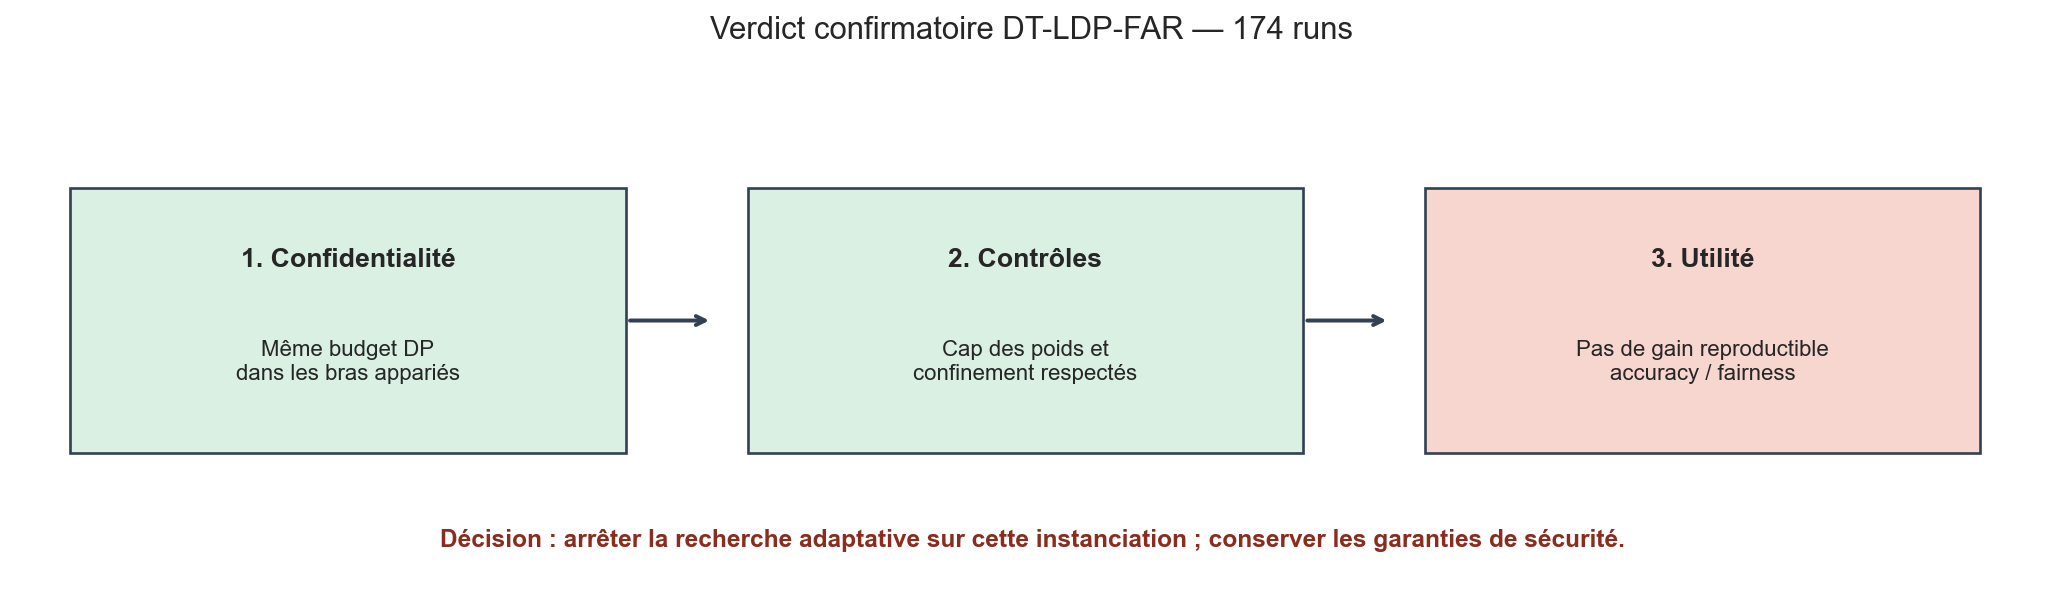

In [15]:
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.set_xlim(0, 3)
ax.set_ylim(0, 1)
ax.axis("off")

boxes = [
    (0.08, "1. Confidentialité", "Même budget DP\ndans les bras appariés", "#D9F0E3"),
    (1.08, "2. Contrôles", "Cap des poids et\nconfinement respectés", "#D9F0E3"),
    (2.08, "3. Utilité", "Pas de gain reproductible\naccuracy / fairness", "#F7D6D0"),
]
for x, title, body, color in boxes:
    ax.add_patch(plt.Rectangle((x, 0.24), 0.82, 0.52, facecolor=color,
                               edgecolor="#334155", linewidth=1.2))
    ax.text(x + 0.41, 0.62, title, ha="center", va="center",
            fontsize=12, weight="bold")
    ax.text(x + 0.41, 0.42, body, ha="center", va="center", fontsize=10)
for x in (0.93, 1.93):
    ax.annotate("", xy=(x + 0.10, 0.50), xytext=(x - 0.03, 0.50),
                arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#334155"})

ax.text(
    1.5, 0.07,
    "Décision : arrêter la recherche adaptative sur cette instanciation ; "
    "conserver les garanties de sécurité.",
    ha="center", va="center", fontsize=11, weight="bold", color="#8A2D1E"
)
ax.set_title(
    f"Verdict confirmatoire DT-LDP-FAR — {final_decision['evaluated_runs']} runs",
    fontsize=14, pad=12,
)
save_show(fig, "dt_ldp_far_final_negative_decision.png");

,Stage,Runs,Gain attaqué moyen (pp),Coût propre moyen (pp),Bit-Flip (pp),IPM (pp),Hypothèse validée
0,22,24,-0.395,-0.030,-0.557,-0.233,False
1,23,36,0.862,-1.503,-0.230,1.953,False
2,24,36,-2.725,-4.447,-3.493,-1.957,False
3,25,36,-7.183,-0.607,0.250,-14.617,False
4,26B,27,1.232,-0.270,2.703,-0.240,False


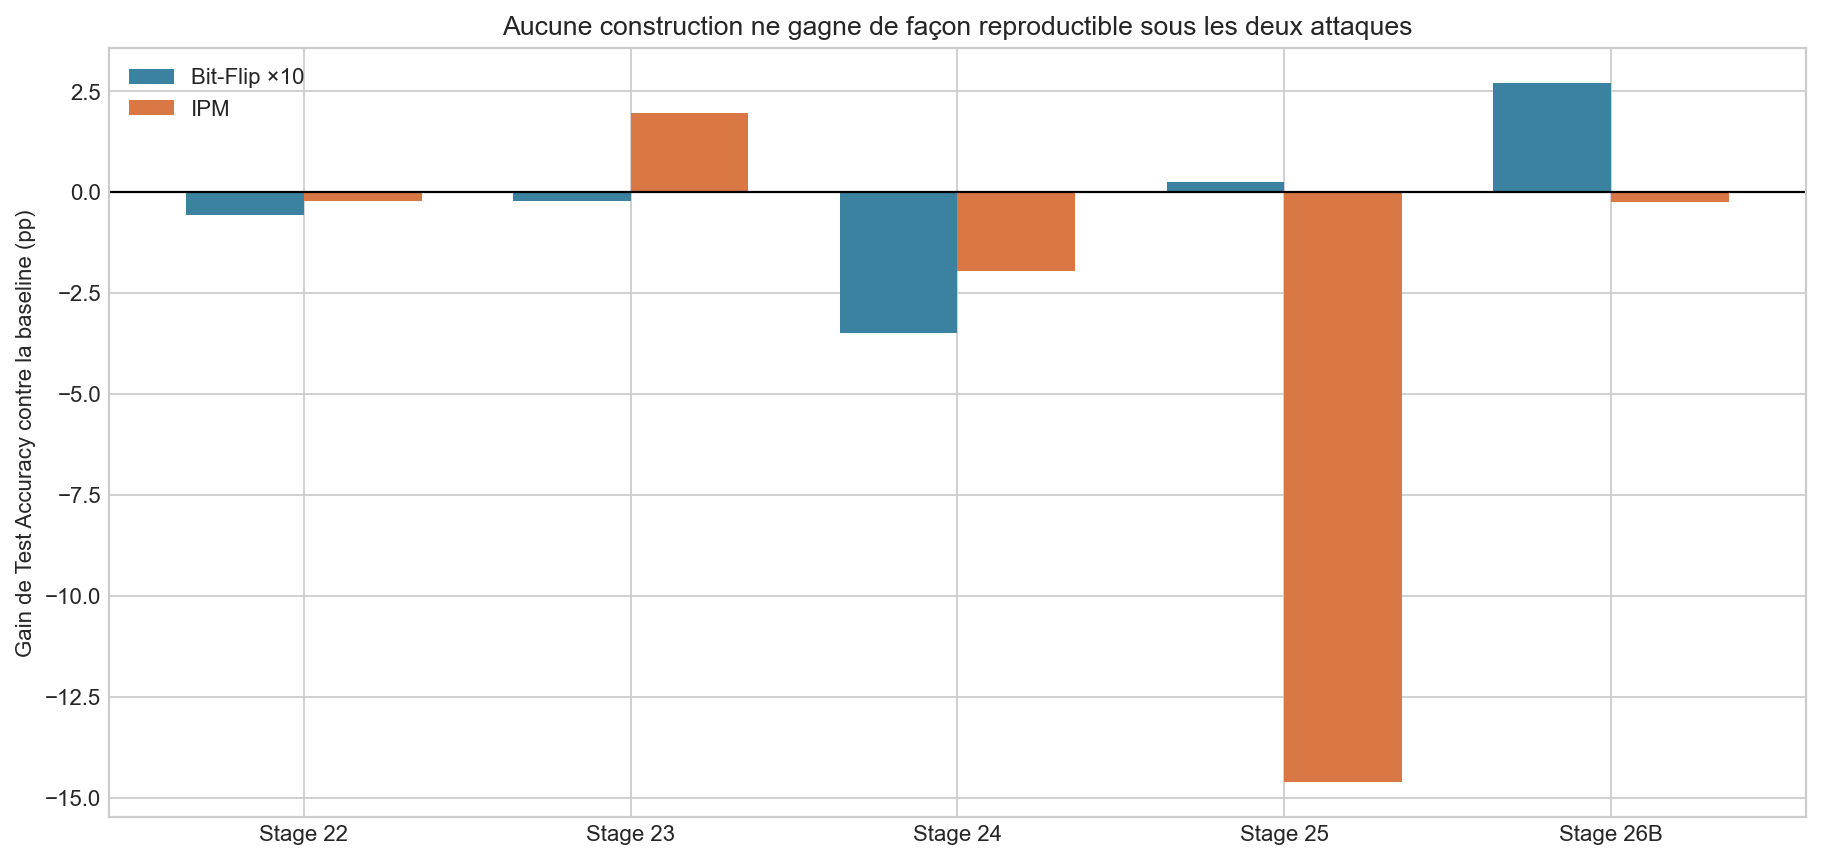

In [16]:
stage_decision_specs = [
    (
        "22", "stage22_lagged_descent_validation_v1/stage22_decision.json",
        "separated_accuracy_gain_mean_pp", "no_attack_accuracy_difference_mean_pp",
        "accuracy_gain_mean_by_attack_pp", "lagged_descent_hypothesis_validated",
    ),
    (
        "23", "stage23_robust_admissibility_validation_v1/stage23_decision.json",
        "integrated_attacked_accuracy_gain_mean_pp", "integrated_clean_accuracy_mean_pp",
        "integrated_attacked_accuracy_gain_by_attack_pp", "stage23_fully_validated",
    ),
    (
        "24", "stage24_multikrum_admissibility_validation_v1/stage24_decision.json",
        "integrated_attacked_accuracy_gain_mean_pp", "integrated_clean_accuracy_mean_pp",
        "integrated_attacked_accuracy_gain_by_attack_pp", "stage24_fully_validated",
    ),
    (
        "25", "stage25_robust_anchor_containment_validation_v1/stage25_decision.json",
        "candidate_attacked_accuracy_gain_mean_pp", "candidate_clean_accuracy_mean_pp",
        "candidate_attacked_accuracy_gain_by_attack_pp", "stage25_fully_validated",
    ),
    (
        "26B", "stage26b_trmean_nnm_anchor_confirmatory_v1/stage26b_decision.json",
        "candidate_attacked_accuracy_gain_mean_pp", "candidate_clean_accuracy_mean_pp",
        "candidate_attacked_accuracy_gain_by_attack_pp", "stage26_fully_validated",
    ),
]

stage_utility_rows = []
for stage, relative_path, attacked_key, clean_key, attacks_key, verdict_key in stage_decision_specs:
    payload = read_json(REPO_ROOT / "results" / "dt_ldp_far" / relative_path)
    observations = payload["observations"]
    by_attack = observations[attacks_key]
    stage_utility_rows.append({
        "Stage": stage,
        "Runs": payload["completed_runs"],
        "Gain attaqué moyen (pp)": observations[attacked_key],
        "Coût propre moyen (pp)": observations[clean_key],
        "Bit-Flip (pp)": by_attack["bf20_n25_s10"],
        "IPM (pp)": by_attack["ipm20_n25"],
        "Hypothèse validée": bool(payload.get(verdict_key, False)),
    })

stage_utility = pd.DataFrame(stage_utility_rows)
display(stage_utility.round(3))
stage_utility.to_csv(
    EXPORT_ROOT / "dt_ldp_far_utility_failures_by_stage.csv", index=False
)

fig, ax = plt.subplots(figsize=(11.5, 5.5))
x = np.arange(len(stage_utility))
width = 0.36
ax.bar(
    x - width / 2, stage_utility["Bit-Flip (pp)"], width,
    label="Bit-Flip ×10", color="#3B82A0",
)
ax.bar(
    x + width / 2, stage_utility["IPM (pp)"], width,
    label="IPM", color="#D97745",
)
ax.axhline(0.0, color="black", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels([f"Stage {value}" for value in stage_utility.Stage])
ax.set_ylabel("Gain de Test Accuracy contre la baseline (pp)")
ax.set_title("Aucune construction ne gagne de façon reproductible sous les deux attaques")
ax.legend()
save_show(fig, "dt_ldp_far_utility_failure_by_attack.png");

### Preuve expérimentale de l'échec d'utilité

Une moyenne globale positive ne suffit pas. Le Stage 23 gagne sous IPM mais
perd sous Bit-Flip et dégrade l'accuracy sans attaque. Le Stage 26B gagne sous
Bit-Flip mais perd sous IPM. Les Stages 22, 24 et 25 ont un gain attaqué moyen
négatif. Aucun stage ne satisfait donc simultanément les gates préenregistrés
sur les deux attaques, le coût propre et la répétabilité entre seeds.

Le résultat négatif ne repose pas sur une unique moyenne : il repose sur
l'absence d'une amélioration de même signe dans les conditions confirmatoires.

### Comment lire le verdict

- **Ce qui fonctionne :** la privacy locale, l'appariement expérimental, le
  contrôle de la concentration et la borne déterministe de correction.
- **Ce qui échoue :** ces propriétés ne se transforment pas en amélioration
  reproductible de l'accuracy ou de la fairness. Au Stage 26B, la correction
  FAR apporte en moyenne environ $-0{,}032$ point sous attaque et
  $-0{,}027$ point sans attaque.
- **Pourquoi arrêter :** les Stages 22 à 26 testent plusieurs constructions sur
  des holdouts indépendants. Continuer à modifier les mêmes seuils après avoir
  observé ces échecs reviendrait à entraîner la méthode sur les données de
  validation.
- **Ce qui reste scientifiquement possible :** une nouvelle piste local-DP doit
  partir d'une hypothèse substantiellement différente, d'un objectif renouvelé
  et d'un nouveau holdout. Ce verdict n'est pas un théorème d'impossibilité de
  la local-DP.

La formulation défendable est donc : **DT-LDP-FAR est sûr au sens des
invariants vérifiés, mais sa supériorité d'utilité est rejetée dans le protocole
Fashion-MNIST étudié.**

## 7. Tableau de synthèse

In [17]:
verdicts = pd.DataFrame([
    {
        "Question": "Faut-il contrôler α ?",
        "Périmètre": "n=10, deux partitions, seed de stress 54",
        "Verdict": "Oui : soutenu empiriquement et justifié analytiquement",
        "Réserve": "Pas une loi universelle de monotonie",
    },
    {
        "Question": "Le retard améliore-t-il l'utilité ?",
        "Périmètre": "n=10, même seed/bruit/configuration",
        "Verdict": "Non soutenu dans le régime testé",
        "Réserve": "Poids trop proches de l'uniforme ; stress insuffisant",
    },
    {
        "Question": "Le clipping serveur est-il utile ?",
        "Périmètre": "ancien screen n=25, une seed",
        "Verdict": "Oui contre Bit-Flip de grande norme ; non contre ALIE furtive",
        "Réserve": "Ancienne géométrie saturée ; refaire l'ablation recalibrée",
    },
    {
        "Question": "Le score doit-il être standardisé par le bruit DP ?",
        "Périmètre": "Stage 5, n=25, 4 configurations, 3 seeds",
        "Verdict": "Hypothèse fortement motivée, méthode pas encore testée",
        "Réserve": "Le diagnostic utilise un oracle ; comparer les scores dans une campagne dédiée",
    },
    {
        "Question": "F_CC est-elle empiriquement la meilleure ?",
        "Périmètre": "ancien screen n=25, une seed",
        "Verdict": "Non démontré",
        "Réserve": "Conserver Huber et RFA comme ablations",
    },
])
display(verdicts)
verdicts.to_csv(EXPORT_ROOT / "scientific_verdicts.csv", index=False)
print("Exports écrits dans :", EXPORT_ROOT)

,Question,Périmètre,Verdict,Réserve
0,Faut-il contrôler α ?,"n=10, deux partitions, seed de stress 54",Oui : soutenu empiriquement et justifié analyt...,Pas une loi universelle de monotonie
1,Le retard améliore-t-il l'utilité ?,"n=10, même seed/bruit/configuration",Non soutenu dans le régime testé,Poids trop proches de l'uniforme ; stress insu...
2,Le clipping serveur est-il utile ?,"ancien screen n=25, une seed",Oui contre Bit-Flip de grande norme ; non cont...,Ancienne géométrie saturée ; refaire l'ablatio...
3,Le score doit-il être standardisé par le bruit...,"Stage 5, n=25, 4 configurations, 3 seeds","Hypothèse fortement motivée, méthode pas encor...",Le diagnostic utilise un oracle ; comparer les...
4,F_CC est-elle empiriquement la meilleure ?,"ancien screen n=25, une seed",Non démontré,Conserver Huber et RFA comme ablations


Exports écrits dans : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/output/analysis/dt_ldp_far_n10_notebook


## 8. Limites à rappeler dans toute présentation

- Le stress α complet à n=10 ne porte que sur la seed 54.
- Les comparaisons n=10 courant/retardé sont des screens courts de 20 rounds.
- Le contrôle courant est utile pour l'analyse de trajectoire, mais ses diagnostics
  oracle ne constituent pas un transcript LDP publiable.
- Les écrans clipping/références reproduits ici sont à n=25, sur l'ancienne
  géométrie et une seule seed.
- Une expérience ne « prouve » pas la nécessité mathématique d'un cap sur α : elle
  peut montrer le phénomène et falsifier une configuration. Le certificat fournit
  la garantie formelle.
- Stage 5 soutient un **confondant d'échelle DP**, pas encore la supériorité d'une pondération covariance-aware.
- Le diagnostic normalisé emploie la perturbation contrefactuelle oracle ; il sert à l'analyse mécanistique et ne doit pas être publié dans le transcript LDP.
- Stage 5 soutient un **confondant d'échelle DP**, pas encore la supériorité d'une pondération covariance-aware.
- Le diagnostic normalisé emploie la perturbation contrefactuelle oracle ; il sert à l'analyse mécanistique et ne doit pas être publié dans le transcript LDP.
